---
#**SOURCED DATASET PREPROCESSING**
---


### **Sourced Dataset Preprocessing Overview**
The sports articles dataset underwent a comprehensive preprocessing pipeline to prepare the text for NLP tasks. This included lowercasing, URL and special character removal, stopword filtering, tokenization, and lemmatization. Each step was applied to standardize the content, reduce noise, and preserve meaningful information such as player names, scores, and key game events. The resulting dataset is clean, structured, and ready for analysis or modeling.


---

##**LIBRARIES INSTALLATION**

---


In [ ]:
!pip install contractions
!pip install spacy
!python -m spacy download en_core_web_sm
!pip install rouge-score

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 92.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
  Preparing metadata (setup.py) ... done
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=28cb7a4cd9192759311a3274d3b03ff4b97b2c4ad497b57af390d06dc2a19a62
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge-score


### **Function Description**  
This block installs the required libraries for preprocessing sports articles. It ensures that contraction handling and natural language processing tools are available in the environment.  

### **Syntax Explanation**  
- `!pip install contractions` installs the contractions library which expands shortened words such as can't into cannot.  
- `!pip install spacy` installs the spaCy library which is used for tokenization, lemmatization, and stopword removal.  
- `!python -m spacy download en_core_web_sm` downloads the English language model for spaCy which contains pretrained components for text processing.  

### **Inputs**  
There are no direct input files for this step. The commands are applied to the environment in Google Colab or Jupyter Notebook.  

### **Outputs**  
The output is the installation of the required libraries and the spaCy English model which will be used in the later preprocessing steps.  

### **Code Flow**  
1. Install the contractions library.  
2. Install the spaCy library.  
3. Download the English spaCy model.  

### **Comments and Observations**  
- The contractions library was installed to expand shortened words, ensuring standardized text for preprocessing.
- The spaCy library was installed along with the English language model, enabling tokenization, lemmatization, and stopword removal.
- These installations are prerequisites for subsequent preprocessing steps; without them, later text normalization functions would not execute.
- Installation is required only once per runtime session in Google Colab.

In [ ]:
import pandas as pd
import numpy as np
import re
import nltk
import html
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import contractions
import spacy
from nltk.corpus import wordnet
from nltk import pos_tag
import matplotlib.pyplot as plt


nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

### **Function Description**  
This block imports the required Python libraries for preprocessing sports articles and downloads the necessary resources from the Natural Language Toolkit (NLTK). These libraries will be used for text cleaning, tokenization, lemmatization, and linguistic analysis.  

### **Syntax Explanation**  
- `import pandas as pd` and `import numpy as np` are used for handling and processing structured data.  
- `import re` and `import html` provide regular expressions and HTML handling for text cleaning.  
- `from nltk.corpus import stopwords` loads the stopwords list to remove common words such as the and is.  
- `from nltk.tokenize import word_tokenize` allows splitting text into individual words.  
- `from nltk.stem import WordNetLemmatizer` reduces words to their base form such as running to run.  
- `import contractions` expands shortened forms such as don’t to do not.  
- `import spacy` loads spaCy for advanced NLP tasks such as tokenization and POS tagging.  
- `from nltk.corpus import wordnet` provides synonyms and word relationships used for lemmatization.  
- `from nltk import pos_tag` performs part of speech tagging.  
- `import matplotlib.pyplot as plt` is used for creating visualizations.  
- `nltk.download(...)` commands download required NLTK datasets such as stopwords, tokenizers, and tagging models.  

### **Inputs**  
There are no direct input datasets in this block. The inputs are the external libraries and language resources being imported and downloaded.  

### **Outputs**  
The output is a ready-to-use programming environment with all necessary NLP libraries and resources installed.  

### **Code Flow**  
1. Import general data analysis libraries such as pandas and numpy.  
2. Import text cleaning and NLP libraries such as re, nltk, contractions, and spacy.  
3. Download NLTK resources including stopwords, tokenizers, wordnet, and POS taggers.  

### **Comments and Observations**  
- Core libraries for data handling (pandas, numpy) and text cleaning (re, html) were imported to support structured preprocessing tasks
- NLP-specific libraries such as nltk, spacy, and contractions were included to enable tokenization, lemmatization, contraction expansion, and POS tagging
- NLTK resources including stopwords, tokenizers, and WordNet were downloaded to support linguistic analysis
- Overlap exists between nltk and spacy, but having both provides flexibility for handling different preprocessing requirements
- These imports and downloads are prerequisites; later steps such as stopword removal, lemmatization, and tagging would not function without them


---

##**IMPORT AND LOAD OF DATASET**

---


In [ ]:
df = pd.read_csv('sports_data.csv')

pd.set_option('display.max_colwidth', None)

df.head(10)

headlines  \
0                    Jannik Sinner’s strong and improved baseline game helps him stun Novak Djokovic to reach Australian Open final   
1                Allan Border opens up about Parkinson’s disease: ‘I’m not scared, but I am worried about the slow decline process’   
2                    Australian Open 2024: Jannik Sinner stops Novak Djokovic’s bid to win 11th Australian Open and 25th Grand Slam   
3                                                   ‘It looked like a dead lbw’: Ben Duckett on Shubman Gill surviving a close call   
4                                In crunch time, Kiran George produces an aggressive finish to beat China’s World No.19 Lu Guang Zu   
5  Sarfaraz and Musheer: Two brothers, 7,625km apart, one scored a century for India A, the other for India colts in U-19 World Cup   
6    Australian Open: Jannik Sinner can match Novak Djokovic in his game, but can he emulate the Serb’s appetite for the big stage?   
7                                                     IND vs ENG: How India’s batsmen capitalised on England’s callow bowling group   
8                                       Shakib Al Hasan diagnosed with retinal condition in left eye, will continue to play cricket   
9                                 Virat Kohli named 2023 ICC ODI cricketer of the year, Pat Cummins wins Sir Garfield Sobers Trophy   

                                                                                                                                                                                                      description  \
0                Baseline strategy has been central to Jannik Sinner's game and he has been working on it with his new coaching team since the start of 2022 – led by Darren Cahill, Andre Agassi’s former coach.   
1                                                                                              Former Australia captain says the disease has softened him a bit, which is embarrassing and good at the same time.   
2                                                                                                                            Sinner defeated Djokovic 6-1, 6-2, 6-7, 6-3 in the semfinals of the Australian Open.   
3                                                                                              Duckett believes England are still in the game and they can take wickets in cluster to put India on the back foot.   
4     As Kiran George had missed out on opportunities to go deeper into draws, his coaches at the Prakash Padukone academy in Bangalore had been drilling into him the importance of a strong, aggressive finish.   
5                                                                                 Father Naushad Khan gives credit to Mumbai’s khadoos cricket in both sons’ journeys, says Sarfaraz will get his India cap soon.   
6                                                                                     Italian has beaten World No.1 in two their last three meetings, but the legend is usually at his best late in a Grand Slam.   
7                                                                                                 With just one seamer, a spin pair with an experience of one game, Jaiswal made merry of England’s inexperience.   
8  The condition is unlikely to stop him from playing competitive cricket with the 36-year-old looking set to appear for Rangpur Riders in their Bangladesh Premier League match against Khulna Tigers on Friday.   
9     Cummins, who marked the year by lifting the ODI World Cup and the World Test Championship titles and also retaining the Ashes in England, beat Kohli in the race to become the men's cricketer of the year.   

                                                                                                                                                                                                                                                                                                    

### **Function Description**  
This block loads the sports dataset from a CSV file and displays the first ten rows. It also adjusts the display settings to show the full text in each column without cutting it off.  

### **Syntax Explanation**  
- `pd.read_csv('sports_data.csv')` reads the CSV file named sports_data.csv into a pandas DataFrame.  
- `pd.set_option('display.max_colwidth', None)` removes the limit on column width so that long text fields such as article content are displayed fully.  
- `df.head(10)` displays the first ten rows of the DataFrame for inspection.  

### **Inputs**  
- The input is the file `sports_data.csv`, which contains the sports articles dataset.  
- This dataset includes columns such as headline, description, and content.  

### **Outputs**  
- The output is a pandas DataFrame named `df`.  
- The first ten rows of the dataset are displayed in tabular format for quick review.  

### **Code Flow**  
1. Read the dataset into a DataFrame.  
2. Set the display option to show full text in cells.  
3. Display the first ten rows of the dataset.  

### **Comments and Observations**  
- The dataset was successfully loaded into a pandas DataFrame using pd.read_csv
- Display settings were adjusted to show the full text of long fields such as article content
- Viewing the first ten rows provided confirmation that the file was read correctly
- The preview also revealed the dataset structure including columns like headline, description, and content
- This inspection step supports planning for later preprocessing tasks such as text cleaning and labeling

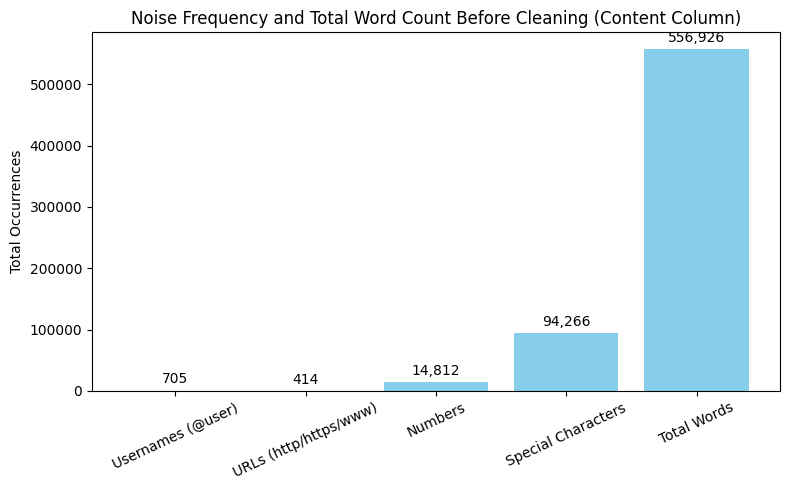

In [ ]:
import matplotlib.pyplot as plt

# Patterns to detect common "noise" in news content
patterns = {
    'Usernames (@user)': r'@\w+',
    'URLs (http/https/www)': r'http\S+|www\S+|https\S+|pic\.twitter\S+',
    'Numbers': r'\b\d+\b',
    'Special Characters': r'[^A-Za-z0-9\s]'
}

noise_counts_before = {
    label: df['content'].str.count(pattern).sum()
    for label, pattern in patterns.items()
}

total_words_before = df['content'].str.split().apply(len).sum()
noise_counts_before['Total Words'] = total_words_before

plt.figure(figsize=(8, 5))
bars = plt.bar(noise_counts_before.keys(), noise_counts_before.values(), color='skyblue')
plt.title('Noise Frequency and Total Word Count Before Cleaning (Content Column)')
plt.ylabel('Total Occurrences')
plt.xticks(rotation=25)

for bar in bars:
    height = bar.get_height()
    plt.annotate(f'{int(height):,}',
                 xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 3),
                 textcoords='offset points',
                 ha='center', va='bottom')

plt.tight_layout()
plt.show()

### **Function Description**  
This block identifies and counts noisy elements in the sports articles, such as usernames, URLs, numbers, and special characters. It also calculates the total word count in the content column. A bar chart is generated to visualize the frequency of these elements before preprocessing.  

### **Syntax Explanation**  
- `patterns` defines regular expressions for detecting usernames, URLs, numbers, and special characters.  
- `df['content'].str.count(pattern).sum()` counts how many times each pattern appears across all rows of the content column.  
- `df['content'].str.split().apply(len).sum()` calculates the total number of words.  
- `plt.bar(...)` creates a bar chart to compare the frequency of noise elements and total words.  
- `plt.annotate(...)` adds numerical labels on top of each bar for clarity.  

### **Inputs**  
- Input is the `content` column of the DataFrame `df`, which contains the full text of the sports articles.  

### **Outputs**  
- A dictionary `noise_counts_before` containing counts for usernames, URLs, numbers, special characters, and total words.  
- A bar chart visualizing the frequency of these elements.  

### **Code Flow**  
1. Define regex patterns for common noisy elements.  
2. Count occurrences of each noise type in the content column.  
3. Calculate total word count.  
4. Store results in a dictionary.  
5. Create and display a bar chart with counts and annotations.  

### **Comments and Observations**  
- Noise elements such as usernames, URLs, numbers, and special characters were quantified using regex patterns
- Total word count in the content column was calculated for comparison with noisy elements
- A bar chart was generated to visualize the relative frequency of noise types versus total words
- Sports articles were shown to include common noise such as scores, dates, links, and emojis
- The results confirm the necessity of preprocessing steps like URL filtering, number handling, and special character removal


In [ ]:
df = df.drop(columns=['url', 'category'])

df.head()

headlines  \
0      Jannik Sinner’s strong and improved baseline game helps him stun Novak Djokovic to reach Australian Open final   
1  Allan Border opens up about Parkinson’s disease: ‘I’m not scared, but I am worried about the slow decline process’   
2      Australian Open 2024: Jannik Sinner stops Novak Djokovic’s bid to win 11th Australian Open and 25th Grand Slam   
3                                     ‘It looked like a dead lbw’: Ben Duckett on Shubman Gill surviving a close call   
4                  In crunch time, Kiran George produces an aggressive finish to beat China’s World No.19 Lu Guang Zu   

                                                                                                                                                                                                   description  \
0             Baseline strategy has been central to Jannik Sinner's game and he has been working on it with his new coaching team since the start of 2022 – led by Darren Cahill, Andre Agassi’s former coach.   
1                                                                                           Former Australia captain says the disease has softened him a bit, which is embarrassing and good at the same time.   
2                                                                                                                         Sinner defeated Djokovic 6-1, 6-2, 6-7, 6-3 in the semfinals of the Australian Open.   
3                                                                                           Duckett believes England are still in the game and they can take wickets in cluster to put India on the back foot.   
4  As Kiran George had missed out on opportunities to go deeper into draws, his coaches at the Prakash Padukone academy in Bangalore had been drilling into him the importance of a strong, aggressive finish.   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        

### **Function Description**  
This block removes the `url` and `category` columns from the DataFrame since they are not needed for NLP preprocessing or modeling. It simplifies the dataset to focus only on the content and tokenized textual information.

### **Syntax Explanation**  
- `df.drop(columns=['url', 'category'])` removes the specified columns from the DataFrame.  
- `df.head()` displays the first few rows of the updated DataFrame to confirm the columns were dropped.

### **Inputs**  
- `df`: The original DataFrame containing all columns including `url` and `category`.

### **Outputs**  
- The DataFrame `df` without the `url` and `category` columns.  
- A preview of the first few rows showing that the columns have been successfully removed.

### **Code Flow**  
1. Identify columns that are unnecessary for text analysis (`url` and `category`).  
2. Use `drop()` to remove them from the DataFrame.  
3. Display the first few rows using `head()` to verify the change.

### **Comments and Observations**  
- The url and category columns were removed from the DataFrame as they are not relevant for NLP preprocessing or modeling
- Keeping only necessary text-based columns ensures the dataset remains clean and focused
- Eliminating unused fields reduces memory usage and improves processing efficiency
- For NLP tasks, the primary requirement is the textual content along with essential labeled features
- This refinement prepares the dataset for streamlined preprocessing and model training

---

##**LOWERCASING THE DATASET**

---

In [ ]:
testcase_text = df.loc[3, 'content']
print(testcase_text)

England opener Ben Duckett says Shubman Gill surviving a close call looked like a “dead lbw” and still believes that if they can take wickets in cluster to put India on the back foot.
“It feels like a tricky pitch to start on,” he told reporters.
“Shubman (Gill) there, we could have had him. It looked like a dead lbw (when he was struck on the pad by Tom Hartley) and somehow, it’s bouncing over the stumps. It’s one of those things.
“We’ll stick to our mantra and that’s taking wickets and looking to be positive. Hopefully, that will happen for us as well.”
India will resume from 119 for 1 on Day 2 and Yashasvi Jaiswal’s attacking gameplan has taken England by surprise but with pitch deteriorating quickly, England are still in the match.
“You have to pay credit to them… they played really well and were very attacking, which is positive,” he said.
“They don’t always go about it like that, so to go about it that way shows that they probably think that pitch is going to get quite a bit wors

### **Function Description**  
This block selects one sports article from the dataset to serve as a test case for preprocessing. It prints the full text of the article content so that changes at each cleaning step can be compared later.  

### **Syntax Explanation**  
- `df.loc[3, 'content']` accesses the row with index 3 from the DataFrame and retrieves the value from the content column.  
- `print(testcase_text)` displays the article text in the output cell.  

### **Inputs**  
- Input is the DataFrame `df` containing sports articles.  
- Specifically, the content field of the article at row index 3 is used.  

### **Outputs**  
- A single article text is printed in its raw form, before any preprocessing.  

### **Code Flow**  
1. Select the article text at row index 3 from the content column.  
2. Store it in the variable `testcase_text`.  
3. Print the selected article text for inspection.  

### **Comments and Observations**  
- Inspecting the unprocessed article helps visualize the presence of noise such as URLs, numbers, or special characters
- Using a fixed test case allows direct comparison of transformations across each preprocessing step
- This approach supports clearer evaluation of preprocessing effectiveness


In [ ]:
lowercased_test = testcase_text.lower()
print( lowercased_test)

england opener ben duckett says shubman gill surviving a close call looked like a “dead lbw” and still believes that if they can take wickets in cluster to put india on the back foot.
“it feels like a tricky pitch to start on,” he told reporters.
“shubman (gill) there, we could have had him. it looked like a dead lbw (when he was struck on the pad by tom hartley) and somehow, it’s bouncing over the stumps. it’s one of those things.
“we’ll stick to our mantra and that’s taking wickets and looking to be positive. hopefully, that will happen for us as well.”
india will resume from 119 for 1 on day 2 and yashasvi jaiswal’s attacking gameplan has taken england by surprise but with pitch deteriorating quickly, england are still in the match.
“you have to pay credit to them… they played really well and were very attacking, which is positive,” he said.
“they don’t always go about it like that, so to go about it that way shows that they probably think that pitch is going to get quite a bit wors

### **Function Description**  
This block converts the selected article text into lowercase. It ensures consistency by treating words with different cases as the same during analysis.  

### **Syntax Explanation**  
- `testcase_text.lower()` transforms all characters in the string to lowercase.  
- `print(lowercased_test)` displays the processed text.  

### **Inputs**  
- The input is the variable `testcase_text`, which contains the raw article text.  

### **Outputs**  
- The output is the same article text but with all characters converted to lowercase, stored in `lowercased_test`.  

### **Code Flow**  
1. Apply the `.lower()` method to the article text.  
2. Store the lowercase version in `lowercased_test`.  
3. Print the transformed text to observe the change.  

### **Comments and Observations**  
- The article text was converted to lowercase to ensure case consistency across all tokens  
- Lowercasing prevents duplication of tokens that differ only by capitalization, such as Team and team  
- This step is essential in sports articles where names and terms often appear with varied capitalization  
- Standardizing text at this stage improves the accuracy of later tokenization and frequency analysis

In [ ]:
df['content'] = df['content'].apply(lambda x: str(x).lower())

df[['content']].head(10)

content
0                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             in a resolute, nerveless, three-hour-long display of destructive shot making and tactical mastery, jannik sinner, the rising 22-year-old world no.4, defeated novak djokovic 6-1, 6-2, 6-7 (6), 6-3 in the semifinals of the australian open on friday, reaching his first major final and becoming the first italian man to reach the singles final in melbourne.\nsinner outplayed and outmanoeuvred the undisputed king of melbourne park – and men’s tennis in general – and in doing so, not only strengthened his long-held credentials as a potential great in the making, but also achieved a feat that none of the serb’s greatest rivals had been able to accomplish even at the peak of their careers.\nprior to friday, 10-time champion djokovic had never lost in the semifinal or final of the australian open. a perfect 20-0 record. he was 33 matches unbeaten in melbourne, a streak that went back to 2018 – 2195 days, as the broadcasters were keen to point out every chance they got.\nsavour the moment @janniksin 🥕#ausopen • #ao2024 pic.twitter.com/ftsdsa2aop\n— #ausopen (@australianopen) january 26, 2024\nthe serb’s dominance of the slams, and particularly melbourne park, was not simply down to extraordinary tennis repertoire, but instead part of a legacy built on a near-supernatural ability to expose best-of-five tennis for the collection of short sprints that it is, as opposed to the consistent long run marathon it has always been claimed to be.\neven when thoroughly outplayed, djokovic has always possessed the athleticism and presence of mind to take matches deep, win the pressure points, keep himself competitive enough to give himself a chance to win the match in the finer margins.\nso, sinner’s statement-making victory was not completed during the first half of the match, when the solid italian took advantage of a streaky-looking djokovic to race into an early two-set lead. instead, it was earned during the second half, when he prevented the 24-time grand slam champion, who raised his game to try to take the contest deep, from completing one of his signature comebacks.\nsuperior in all departments\ndjokovic was unquestionably flat at the start of this match, and his second-half recovery was never too convincing either, similar to his level in his first five matches of the tournament. out of 90 completed points in the first two sets, djokovic made 29 unforced errors.\nhe would admit to this himself, cutting a disappointed figure in his post-match press conference. “i was, in a way, shocked with my level, in a bad way,” he said. “this is one of the worst grand slam matches i’ve ever played, at least that i remember… this tournament hasn’t been, as i said, up to my standard or criteria or the level that i would normally play or expect myself to play”\nand sinner was in diametrically opposite form.\nscintillating sinner 🇮🇹🔥\nhe achieves the impossible defeating 10x #ausopen champion djokovic 6-1 6-2 6-7(6) 6-3.@janniksin • #ao2024 • @wwos • @espn • @eurosport • @wowowtennis@kia_worldwide • #kia • #makeyourmove pic.twitter.com/x6qfategq7\n— #ausopen (@australianopen) january 26, 2024\nbaseline strategy has formed a primary emphasis of the work he has been doin

### **Function Description**  
This block applies lowercasing to the entire dataset instead of just the test case. It ensures that all rows in the content column are standardized to lowercase for consistent text analysis.  

### **Syntax Explanation**  
- `df['content'].apply(lambda x: str(x).lower())` converts each entry in the content column to a string (in case of missing or non-string values) and then applies the `.lower()` method.  
- `df[['content']].head(10)` displays the first ten rows of the cleaned content column.  

### **Inputs**  
- Input is the `content` column of the DataFrame `df`, which contains raw sports article texts.  

### **Outputs**  
- A transformed `content` column where all text has been converted to lowercase.  
- The output preview shows the first ten rows for quick inspection.  

### **Code Flow**  
1. Convert all entries in the content column to lowercase.  
2. Replace the original content column with the transformed version.  
3. Display the first ten rows of the updated column.  

### **Comments and Observations**  
- The entire content column was standardized to lowercase for consistency across all rows  
- Converting all text to lowercase prevents duplication of tokens that differ only by capitalization  
- This step is particularly important in sports articles where team names, player names, and common terms often vary in case  
- Dataset-wide lowercasing ensures uniform input for tokenization, frequency counts, and later modeling tasks  


---
##**CONTRACTIONS EXPANSION**
---

In [ ]:
def expand_contractions(text):
    return contractions.fix(text)

df['content'] = df['content'].apply(expand_contractions)

pd.set_option('display.max_colwidth', None)

df[['content']].head(10)

content
0                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                in a resolute, nerveless, three-hour-long display of destructive shot making and tactical mastery, jannik sinner, the rising 22-year-old world no.4, defeated novak djokovic 6-1, 6-2, 6-7 (6), 6-3 in the semifinals of the australian open on friday, reaching his first major final and becoming the first italian man to reach the singles final in melbourne.\nsinner outplayed and outmanoeuvred the undisputed king of melbourne park – and men’s tennis in general – and in doing so, not only strengthened his long-held credentials as a potential great in the making, but also achieved a feat that none of the serb’s greatest rivals had been able to accomplish even at the peak of their careers.\nprior to friday, 10-time champion djokovic had never lost in the semifinal or final of the australian open. a perfect 20-0 record. he was 33 matches unbeaten in melbourne, a streak that went back to 2018 – 2195 days, as the broadcasters were keen to point out every chance they got.\nsavour the moment @janniksin 🥕#ausopen • #ao2024 pic.twitter.com/ftsdsa2aop\n— #ausopen (@australianopen) january 26, 2024\nthe serb’s dominance of the slams, and particularly melbourne park, was not simply down to extraordinary tennis repertoire, but instead part of a legacy built on a near-supernatural ability to expose best-of-five tennis for the collection of short sprints that it is, as opposed to the consistent long run marathon it has always been claimed to be.\neven when thoroughly outplayed, djokovic has always possessed the athleticism and presence of mind to take matches deep, win the pressure points, keep himself competitive enough to give himself a chance to win the match in the finer margins.\nso, sinner’s statement-making victory was not completed during the first half of the match, when the solid italian took advantage of a streaky-looking djokovic to race into an early two-set lead. instead, it was earned during the second half, when he prevented the 24-time grand slam champion, who raised his game to try to take the contest deep, from completing one of his signature comebacks.\nsuperior in all departments\ndjokovic was unquestionably flat at the start of this match, and his second-half recovery was never too convincing either, similar to his level in his first five matches of the tournament. out of 90 completed points in the first two sets, djokovic made 29 unforced errors.\nhe would admit to this himself, cutting a disappointed figure in his post-match press conference. “i was, in a way, shocked with my level, in a bad way,” he said. “this is one of the worst grand slam matches i have ever played, at least that i remember… this tournament has not been, as i said, up to my standard or criteria or the level that i would normally play or expect myself to play”\nand sinner was in diametrically opposite form.\nscintillating sinner 🇮🇹🔥\nhe achieves the impossible defeating 10x #ausopen champion djokovic 6-1 6-2 6-7(6) 6-3.@janniksin • #ao2024 • @wwos • @espn • @eurosport • @wowowtennis@kia_worldwide • #kia • #makeyourmove pic.twitter.com/x6qfategq7\n— #ausopen (@australianopen) january 26, 2024\nbaseline strategy has formed a primary emphasis of the

### **Function Description**  
This block expands contractions in the text, replacing shortened forms such as don’t or it’s with their full forms like do not or it is. Expanding contractions improves the quality of tokenization and ensures that words are treated consistently during analysis.  

### **Syntax Explanation**  
- `expand_contractions(text)` defines a function that applies `contractions.fix()` to replace contractions with their expanded form.  
- `df['content'].apply(expand_contractions)` applies the function to every entry in the content column.  
- `pd.set_option('display.max_colwidth', None)` ensures that long text entries are displayed in full without being cut off.  
- `df[['content']].head(10)` displays the first ten rows of the updated column.  

### **Inputs**  
- Input is the `content` column of the DataFrame `df`, which contains the article texts.  

### **Outputs**  
- A cleaned version of the `content` column with all contractions expanded.  
- The preview shows the first ten rows of the expanded text.  

### **Code Flow**  
1. Define a function that uses `contractions.fix()` to expand words.  
2. Apply the function to the content column of the dataset.  
3. Replace the original content with the expanded version.  
4. Display the first ten rows for inspection.  

### **Comments and Observations**  
- Contractions in the dataset were expanded to their full forms using the contractions library  
- Expanding shortened words ensures consistency and improves tokenization accuracy  
- This step is important for sports articles that may contain conversational phrases or direct quotes  
- Standardized word forms support better lemmatization, frequency analysis, and sentiment detection  
- The transformation reduces ambiguity by treating words like don’t and do not as the same token

---
##**SPECIAL CHARACTERS REMOVAL**
---

### **URLs Removal**

In [ ]:
df['content'] = df['content'].apply(lambda x: re.sub(r'http\S+|www\S+|https\S+|pic\.twitter\.com/\S+', '', x))

### **Function Description**
Removes URLs from the `content` column, including links starting with http, https, www, and short links from pic.twitter.com. This prevents web addresses from adding noise to the dataset.

### **Syntax Explanation**
- `re.sub(r'http\S+|www\S+|https\S+|pic\.twitter\.com/\S+', '', x)`  
  - `http\S+`, `https\S+`, `www\S+` match standard URLs.  
  - `pic\.twitter\.com/\S+` specifically matches Twitter short links with trailing characters.  
  - `''` replaces the matched URL with an empty string.  
- `.apply(lambda x: ...)` applies this regex substitution to every row in the `content` column.

### **Inputs**
- Input is each row of the `content` column, which may contain embedded URLs or short links.

### **Outputs**
- Output is the same text without any URLs.  
- Example:  
  - Before: `Scintillating Sinner 🔥 pic.twitter.com/x6qfategq7`  
  - After: `Scintillating Sinner 🔥`

### **Code Flow**
1. Go through each row in the `content` column.  
2. Detect any URLs (http, https, www, or pic.twitter.com short links).  
3. Remove them from the text.  

### **Comments and Observations**
- URLs and short links were removed from the content column using regex substitution  
- Eliminating web addresses prevents noise that does not contribute to linguistic analysis  
- Twitter links and embedded references were specifically targeted for removal  
- Sports articles often include external links that are irrelevant for text classification or sentiment analysis  
- Cleaning out URLs ensures the dataset remains focused on meaningful textual information


### **HTML Entities Removal**

In [ ]:
df['content'] = df['content'].apply(lambda x: html.unescape(x))

df['content'] = df['content'].str.replace(r'^rt\s+', '', regex=True)

### **Function Description**  
This block handles two cleaning tasks for the article text:  
1. It removes HTML entities such as `&amp;` or incorrectly encoded characters like `â€™` by converting them into their proper symbols.  
2. It removes leading "rt" tokens, which usually indicate retweets when content includes embedded social media text.  

### **Syntax Explanation**  
- `html.unescape(x)` converts HTML entities into readable characters (for example, `&amp;` becomes `&`).  
- `df['content'].str.replace(r'^rt\s+', '', regex=True)` uses a regular expression to remove the letters `rt` followed by a space at the start of any string.  

### **Inputs**  
- Input is the `content` column of the DataFrame `df`, containing the raw sports article texts.  

### **Outputs**  
- A cleaned version of the `content` column where HTML entities are converted and unnecessary retweet markers are removed.  

### **Code Flow**  
1. Apply `html.unescape` to decode HTML entities across the column.  
2. Apply `str.replace` with regex to strip out `rt` markers from the beginning of article texts.  
3. Save the cleaned text back into the `content` column.  

### **Comments and Observations**  
- HTML entities were decoded into readable characters to improve text clarity  
- Retweet markers (rt) were removed since they add no value to linguistic analysis  
- Cleaning these elements prepares the dataset for smoother downstream preprocessing  

### **Non-aplhanumeric Characters Removal**

In [ ]:
df['content'] = df['content'].apply(lambda x: re.sub(r'[^A-Za-z0-9\s.,!?\'\"-]', '', x))

### **Function Description**  
This block removes unwanted special characters from the article text. It keeps only letters, numbers, spaces, and common punctuation marks such as periods, commas, exclamation points, question marks, and quotation marks.  

### **Syntax Explanation**  
- `re.sub(r'[^A-Za-z0-9\s.,!?\'\"]', '', x)` uses a regular expression to identify characters that are not letters, numbers, spaces, or the allowed punctuation marks.  
- The matched characters are replaced with an empty string, effectively removing them.  
- `df['content'].apply(...)` applies this cleaning step to every row in the content column.  

### **Inputs**  
- Input is the `content` column of the DataFrame `df`, which contains raw sports article texts.  

### **Outputs**  
- A cleaned `content` column where unnecessary characters, such as emojis or unusual symbols, are removed.  

### **Code Flow**  
1. Define a regex pattern that targets unwanted characters.  
2. Apply `re.sub` to remove those characters from each row in the content column.  
3. Replace the original content column with the cleaned version.  

### **Comments and Observations**  
- Special characters such as emojis and unusual symbols were removed from the content column  
- Only letters, numbers, spaces, and common punctuation were retained to preserve readability  
- Cleaning ensures text remains structured and suitable for tokenization and NLP tasks  


### **Extra Spaces Removal**

In [ ]:
df['content'] = df['content'].apply(lambda x: re.sub(r'\s+', ' ', x).strip())

### **Function Description**  
This block removes unnecessary extra spaces from the article text. It ensures that words are separated by a single space and strips any leading or trailing spaces.  

### **Syntax Explanation**  
- `re.sub(r'\s+', ' ', x)` replaces one or more whitespace characters (including tabs, line breaks, and multiple spaces) with a single space.  
- `.strip()` removes any extra spaces at the beginning or end of the string.  
- `df['content'].apply(...)` applies this cleaning step to all rows in the content column.  

### **Inputs**  
- Input is the `content` column of the DataFrame `df`, containing the article texts after previous preprocessing steps.  

### **Outputs**  
- A cleaned `content` column where spacing between words is uniform.  

### **Code Flow**  
1. Use regex to collapse multiple whitespace characters into a single space.  
2. Strip unnecessary spaces from the start and end of each text.  
3. Replace the original column with the cleaned version.  

### **Comments and Observations**  
- Multiple spaces, tabs, and line breaks were collapsed into a single space for uniform text formatting  
- Leading and trailing spaces were removed to standardize the text structure  
- Consistent spacing improves tokenization accuracy and supports smoother preprocessing in later steps


### **Mentions and Hashtags Removal**

In [ ]:
df['content'] = df['content'].apply(lambda x: re.sub(r'[@#]\w+', '', x))

### **Function Description**
Removes mentions and hashtags from the `content` column. Mentions such as @username and hashtags such as #AusOpen are common in sports texts but are not useful for deeper analysis, so they are cleaned out.

### **Syntax Explanation**
- `re.sub(pattern, replacement, string)` replaces text that matches a regex pattern.  
- Pattern: `r'[@#]\w+'`  
  - `[@#]` matches either `@` or `#`.  
  - `\w+` matches one or more word characters following them.  
- Replacement: `''` (an empty string), which deletes the match.

### **Inputs**
- Input is each row of the `content` column containing sports article text.  
- These rows may include mentions like @australianopen or hashtags like #AO2024.

### **Outputs**
- Returns the same text without mentions and hashtags.  
- Example:  
  - Before: `Scintillating Sinner 🇮🇹🔥 #AusOpen @AustralianOpen`  
  - After: `Scintillating Sinner 🇮🇹🔥`

### **Code Flow**
1. Apply a `lambda` function to every row in the `content` column.  
2. Use `re.sub()` to find mentions and hashtags.  
3. Replace them with an empty string.  
4. Return the cleaned text.

### **Comments and Observations**
- Mentions (@username) and hashtags (#topic) were removed from the text using regex substitution  
- These elements act as metadata rather than meaningful linguistic content  
- Sports articles often embed hashtags or tagged accounts that do not contribute to analysis  
- Cleaning them reduces noise and prevents irrelevant tokens from influencing modeling  

### **Newline Markers Removal**

In [ ]:
df['content'] = df['content'].apply(lambda x: x.replace('\n', ' '))

### **Function Description**
Replaces newline characters `\n` with a space in the `content` column. This ensures the text flows continuously instead of being broken into multiple lines.

### **Syntax Explanation**
- `.apply(lambda x: x.replace('\n', ' '))` applies a replacement operation to every row.  
- `x.replace('\n', ' ')` finds every newline character and substitutes it with a single space.

### **Inputs**
- Input is each row of the `content` column, which may contain newline characters (`\n`) separating sentences or paragraphs.

### **Outputs**
- Output is the same text with newline characters replaced by spaces.  
- Example:  
  - Before: `Djokovic said...\nHe added...`  
  - After: `Djokovic said... He added...`

### **Code Flow**
1. Go through each row in the `content` column.  
2. Replace `\n` with a space.  
3. Return the cleaned string.  

### **Comments and Observations**
- Newline characters were replaced with spaces to create continuous text flow  
- Removing line breaks ensures sentences are not split across multiple lines during analysis  
- Uniform formatting improves readability and supports smoother tokenization

### **Emoji Removal**

In [ ]:
emoji_pattern = re.compile(
    "["u"\U0001F600-\U0001F64F"  # emoticons
    u"\U0001F300-\U0001F5FF"     # symbols & pictographs
    u"\U0001F680-\U0001F6FF"     # transport & map symbols
    u"\U0001F1E0-\U0001F1FF"     # flags
    u"\U00002500-\U00002BEF"     # misc symbols
    u"\U00002702-\U000027B0"
    u"\U000024C2-\U0001F251"
    "]+", flags=re.UNICODE)

df['content'] = df['content'].apply(lambda x: emoji_pattern.sub(r'', x))


### **Function Description**
Removes emojis and special Unicode symbols from the `content` column. This step prevents non-textual elements from interfering with NLP processing.

### **Syntax Explanation**
- `re.compile([...], flags=re.UNICODE)` builds a regular expression pattern that matches a wide range of emoji Unicode blocks such as emoticons, flags, pictographs, and symbols.  
- `.sub(r'', x)` replaces any matched emoji with an empty string.  
- `.apply(lambda x: ...)` applies this substitution to every row in the `content` column.

### **Inputs**
- Input is each row of the `content` column, which may contain emojis such as 😀🔥🇮🇹 or symbols like ⚽.  

### **Outputs**
- Output is the same text with all emojis removed.  
- Example:  
  - Before: `Scintillating Sinner 🇮🇹🔥`  
  - After: `Scintillating Sinner`

### **Code Flow**
1. Compile a regex pattern that captures emoji Unicode ranges.  
2. For each row in the `content` column, detect and remove emojis.  
3. Return cleaned text without emojis.  

### **Comments and Observations**
- Emojis and Unicode symbols were removed to eliminate non-textual noise  
- These elements can distort tokenization and reduce model accuracy if left in the dataset  
- Cleaning ensures the text remains consistent and focused on meaningful linguistic features

### **Post-Special Characters Removal Output**

In [ ]:
pd.set_option('display.max_colwidth', None)
df[['content']].head(3)

content
0  in a resolute, nerveless, three-hour-long display of destructive shot making and tactical mastery, jannik sinner, the rising 22-year-old world no.4, defeated novak djokovic 6-1, 6-2, 6-7 6, 6-3 in the semifinals of the australian open on friday, reaching his first major final and becoming the first italian man to reach the singles final in melbourne. sinner outplayed and outmanoeuvred the undisputed king of melbourne park and mens tennis in general and in doing so, not only strengthened his long-held credentials as a potential great in the making, but also achieved a feat that none of the serbs greatest rivals had been able to accomplish even at the peak of their careers. prior to friday, 10-time champion djokovic had never lost in the semifinal or final of the australian open. a perfect 20-0 record. he was 33 matches unbeaten in melbourne, a streak that went back to 2018 2195 days, as the broadcasters were keen to point out every chance they got. savour the moment janniksin ausopen ao2024 ausopen australianopen january 26, 2024 the serbs dominance of the slams, and particularly melbourne park, was not simply down to extraordinary tennis repertoire, but instead part of a legacy built on a near-supernatural ability to expose best-of-five tennis for the collection of short sprints that it is, as opposed to the consistent long run marathon it has always been claimed to be. even when thoroughly outplayed, djokovic has always possessed the athleticism and presence of mind to take matches deep, win the pressure points, keep himself competitive enough to give himself a chance to win the match in the finer margins. so, sinners statement-making victory was not completed during the first half of the match, when the solid italian took advantage of a streaky-looking djokovic to race into an early two-set lead. instead, it was earned during the second half, when he prevented the 24-time grand slam champion, who raised his game to try to take the contest deep, from completing one of his signature comebacks. superior in all departments djokovic was unquestionably flat at the start of this match, and his second-half recovery was never too convincing either, similar to his level in his first five matches of the tournament. out of 90 completed points in the first two sets, djokovic made 29 unforced errors. he would admit to this himself, cutting a disappointed figure in his post-match press conference. i was, in a way, shocked with my level, in a bad way, he said. this is one of the worst grand slam matches i have ever played, at least that i remember this tournament has not been, as i said, up to my standard or criteria or the level that i would normally play or expect myself to play and sinner was in diametrically opposite form. scintillating sinner he achieves the impossible defeating 10x ausopen champion djokovic 6-1 6-2 6-76 6-3.janniksin ao2024 wwos espn eurosport wowowtenniskiaworldwide kia makeyourmove ausopen australianopen january 26, 2024 baseline strategy has formed a primary emphasis of the work he has been doing with his new coaching team led by darren cahill, andre agassis former coach since the start of 2022 and he nailed it in the biggest result of his career. the italians lean, wiry frame and composed demeanour do not betray the full strength of the destructive power that comes off his racquet. his pure ball striking ability would send djokovic trailing to catch balls, and his aggression from start to finish allowed him to finish points before djokovic could even get balls back into play to wear him down. djokovic was out of sorts, but it was sinners baseline prowess that had him totally out of his comfort zone, making him rush his shots and extracting errors. despite it not being the highlight of his game, sinner served exceptionally according to opta, this is the first grand slam match of djokovics 19-year-long career where he did not even have a single break point opportunity. advertisement sinner won 80 of the p

### **Function Description**  
This block displays a preview of the cleaned article texts after preprocessing. It allows verification that the noise removal steps (URLs, HTML entities, special characters, and extra spaces) were applied correctly.  

### **Syntax Explanation**  
- `pd.set_option('display.max_colwidth', None)` ensures that the full text of each article is displayed without truncation.  
- `df[['content']].head(3)` shows the first three rows of the content column.  

### **Inputs**  
- Input is the `content` column of the DataFrame `df`, which now contains the cleaned article texts.  

### **Outputs**  
- A preview of the first three rows of the cleaned content column.  

### **Code Flow**  
1. Adjust Pandas display settings so that long text entries are shown in full.  
2. Select the content column and display the first three rows.  

### **Comments and Observations**  
- Used primarily for validation and quality checks, not transformation  
- Ensures that preprocessing steps (URL, HTML, emoji, spacing cleanup) were applied correctly  
- Helps catch overlooked noise or formatting issues before moving forward  
- Provides confidence that the dataset is clean and ready for downstream NLP tasks  


---
##**STOP WORDS REMOVAL**
---

In [ ]:
stop_words = stopwords.words('english')
print(stop_words)

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

### **Function Description**
Loads the list of English stopwords from the NLTK library. Stopwords are common words such as “the”, “is”, and “and” that usually do not carry significant meaning in NLP tasks.

### **Syntax Explanation**
- `stopwords.words('english')` retrieves a predefined list of English stopwords from NLTK.  
- `print(stop_words)` displays the stopword list so it can be reviewed before applying removal.

### **Inputs**
- The input is the language parameter `'english'`, which tells NLTK to load English stopwords.  

### **Outputs**
- The output is a Python list of English stopwords.  
- Example: `['i', 'me', 'my', 'myself', 'we', 'our', 'ours', ...]`

### **Code Flow**
1. Import the `stopwords` module from NLTK.  
2. Retrieve the list of English stopwords.  
3. Store the list in the variable `stop_words`.  
4. Print the list to verify its contents.  

### **Comments and Observations**
- Stopwords serve as a baseline filter to reduce noise in text data  
- Printing the list first ensures transparency before applying removal  
- Helps confirm that the correct language set (English) is loaded  
- Custom stopwords can later be added or removed depending on domain needs  
- Critical step before tokenization, frequency analysis, or vectorization  

In [ ]:
test_case = df['content'][0]
print(test_case)

final_test = []
for word in test_case.split():
    if word == '' or '\r\n' in word or word in stop_words:
        None
    else:
        final_test.append(word)

print(final_test)
print(' '.join(final_test))

in a resolute, nerveless, three-hour-long display of destructive shot making and tactical mastery, jannik sinner, the rising 22-year-old world no.4, defeated novak djokovic 6-1, 6-2, 6-7 6, 6-3 in the semifinals of the australian open on friday, reaching his first major final and becoming the first italian man to reach the singles final in melbourne. sinner outplayed and outmanoeuvred the undisputed king of melbourne park and mens tennis in general and in doing so, not only strengthened his long-held credentials as a potential great in the making, but also achieved a feat that none of the serbs greatest rivals had been able to accomplish even at the peak of their careers. prior to friday, 10-time champion djokovic had never lost in the semifinal or final of the australian open. a perfect 20-0 record. he was 33 matches unbeaten in melbourne, a streak that went back to 2018 2195 days, as the broadcasters were keen to point out every chance they got. savour the moment janniksin ausopen ao

### **Function Description**
Demonstrates how stopwords are removed from a sample article by filtering out common words that carry little meaning. This step shows the difference between the original text and the cleaned version.

### **Syntax Explanation**
- `test_case = df['content'][0]` selects the first row of the `content` column as a sample.  
- `.split()` splits the text into individual words.  
- The loop checks each word:  
  - Skip if the word is empty (`''`), contains carriage returns (`'\r\n'`), or is in the stopword list (`stop_words`).  
  - Otherwise, add it to `final_test`.  
- `' '.join(final_test)` reconstructs the cleaned words into a single string.

### **Inputs**
- Input is a single row of text from the `content` column (sports article).  
- Stopword list (`stop_words`) from NLTK.

### **Outputs**
- `final_test`: a list of words with stopwords removed.  
- `' '.join(final_test)`: the same text reconstructed into a cleaner string without stopwords.  

### **Code Flow**
1. Select one article from the dataset for testing.  
2. Split it into words.  
3. Iterate through each word:  
   - Keep only meaningful tokens.  
4. Collect filtered words into `final_test`.  
5. Print both the word list and the reconstructed text.  

### **Comments and Observations**
- Using a test case makes it easy to visualize how stopwords affect text  
- Splitting and rejoining demonstrates both token-level and sentence-level impact  
- Shows that essential sports terms remain untouched after cleaning  
- Highlights reduction in text size while retaining core meaning  
- Builds confidence before applying stopword removal to the full dataset  

In [ ]:
def remove_stopwords(article, stopwords):
    temp_fnl = []
    for word in article.split():
        if word == '' or '\r\n' in word or word in stopwords:
            None
        else:
            temp_fnl.append(word)
    return ' '.join(temp_fnl)


remove_stopwords(test_case, stop_words)

'resolute, nerveless, three-hour-long display destructive shot making tactical mastery, jannik sinner, rising 22-year-old world no.4, defeated novak djokovic 6-1, 6-2, 6-7 6, 6-3 semifinals australian open friday, reaching first major final becoming first italian man reach singles final melbourne. sinner outplayed outmanoeuvred undisputed king melbourne park mens tennis general so, strengthened long-held credentials potential great making, also achieved feat none serbs greatest rivals able accomplish even peak careers. prior friday, 10-time champion djokovic never lost semifinal final australian open. perfect 20-0 record. 33 matches unbeaten melbourne, streak went back 2018 2195 days, broadcasters keen point every chance got. savour moment janniksin ausopen ao2024 ausopen australianopen january 26, 2024 serbs dominance slams, particularly melbourne park, simply extraordinary tennis repertoire, instead part legacy built near-supernatural ability expose best-of-five tennis collection sho

### **Function Description**
Defines a reusable function `remove_stopwords` that filters out common stopwords, empty tokens, and line breaks from any given article. This prepares the text for cleaner NLP analysis.

### **Syntax Explanation**
- `def remove_stopwords(article, stopwords):` defines a function with two inputs:  
  - `article`: a string (the sports article).  
  - `stopwords`: a list of stopwords to exclude.  
- Inside the function:  
  - `temp_fnl = []` initializes a list to hold filtered words.  
  - The loop checks each word in `article.split()`.  
    - Skip if it’s empty (`''`), contains carriage returns (`'\r\n'`), or is in the stopword list.  
    - Otherwise, append it to `temp_fnl`.  
  - `' '.join(temp_fnl)` reconstructs the list back into a string.  
- `return ' '.join(temp_fnl)` outputs the cleaned article.

### **Inputs**
- `test_case`: the sample article text.  
- `stop_words`: the NLTK English stopwords list.

### **Outputs**
- A cleaned version of the article string with stopwords removed.

### **Code Flow**
1. Define the `remove_stopwords` function.  
2. Pass in a sample article (`test_case`) and the stopword list.  
3. Split the article into words.  
4. Filter out unwanted tokens.  
5. Rejoin and return the filtered words as a clean string.  

### **Comments and Observations**
- Encapsulates stopword removal into a reusable function  
- Makes preprocessing cleaner and easier to apply across full dataset  
- Avoids code duplication compared to manual loops  
- Code cell works on any article string with a given stopword list  
- Output text is shorter but keeps key terms like names, scores, and events  


In [ ]:
df['content'] = df['content'].apply(lambda x: remove_stopwords(x, stop_words))

pd.set_option('display.max_colwidth', None)
df[['content']].head(3)

content
0  resolute, nerveless, three-hour-long display destructive shot making tactical mastery, jannik sinner, rising 22-year-old world no.4, defeated novak djokovic 6-1, 6-2, 6-7 6, 6-3 semifinals australian open friday, reaching first major final becoming first italian man reach singles final melbourne. sinner outplayed outmanoeuvred undisputed king melbourne park mens tennis general so, strengthened long-held credentials potential great making, also achieved feat none serbs greatest rivals able accomplish even peak careers. prior friday, 10-time champion djokovic never lost semifinal final australian open. perfect 20-0 record. 33 matches unbeaten melbourne, streak went back 2018 2195 days, broadcasters keen point every chance got. savour moment janniksin ausopen ao2024 ausopen australianopen january 26, 2024 serbs dominance slams, particularly melbourne park, simply extraordinary tennis repertoire, instead part legacy built near-supernatural ability expose best-of-five tennis collection short sprints is, opposed consistent long run marathon always claimed be. even thoroughly outplayed, djokovic always possessed athleticism presence mind take matches deep, win pressure points, keep competitive enough give chance win match finer margins. so, sinners statement-making victory completed first half match, solid italian took advantage streaky-looking djokovic race early two-set lead. instead, earned second half, prevented 24-time grand slam champion, raised game try take contest deep, completing one signature comebacks. superior departments djokovic unquestionably flat start match, second-half recovery never convincing either, similar level first five matches tournament. 90 completed points first two sets, djokovic made 29 unforced errors. would admit himself, cutting disappointed figure post-match press conference. was, way, shocked level, bad way, said. one worst grand slam matches ever played, least remember tournament been, said, standard criteria level would normally play expect play sinner diametrically opposite form. scintillating sinner achieves impossible defeating 10x ausopen champion djokovic 6-1 6-2 6-76 6-3.janniksin ao2024 wwos espn eurosport wowowtenniskiaworldwide kia makeyourmove ausopen australianopen january 26, 2024 baseline strategy formed primary emphasis work new coaching team led darren cahill, andre agassis former coach since start 2022 nailed biggest result career. italians lean, wiry frame composed demeanour betray full strength destructive power comes racquet. pure ball striking ability would send djokovic trailing catch balls, aggression start finish allowed finish points djokovic could even get balls back play wear down. djokovic sorts, sinners baseline prowess totally comfort zone, making rush shots extracting errors. despite highlight game, sinner served exceptionally according opta, first grand slam match djokovics 19-year-long career even single break point opportunity. advertisement sinner 80 points rallies four shots less, opposed djokovics 43. first two sets, number 32-16, showing well sinner serving returning, keeping points short keep djokovic comfort zone. maintaining composure djokovic subpar throughout match, recovered first two sets reasonably, began raise level enough make sure take advantage player side net buckled. lesser players would tightened one set away biggest result career, sinners concentration never wavered. even djokovic improved, italian stayed true aggressive strategy, served consistently well get line pressure moments take third set tiebreaker, djokovic typically showed signs life recovered match point expertly executed lob less edge tiebreaker. another famous turnaround lurking. lightning fast start janniksin italian captures first set 6-1. ausopen ao2024 ausopen australianopen january 26, 2024 sinner never cowered, coming fourth set done match bombing serves, putting pressure djokovic aggressive return strategy, striking ball purely done start. would djokovic would bli

### **Function Description**
Applies the custom `remove_stopwords` function to every row in the `content` column of the DataFrame. This systematically removes common stopwords from all sports articles.

### **Syntax Explanation**
- `df['content'].apply(lambda x: remove_stopwords(x, stop_words))`:  
  - `.apply()` executes the given function on each element of the `content` column.  
  - `lambda x:` creates an inline anonymous function, passing each row (`x`) into `remove_stopwords`.  
  - `remove_stopwords(x, stop_words)` processes the text and returns a cleaned version without stopwords.  
- `df['content'] = ...` overwrites the original `content` column with the cleaned text.  
- `pd.set_option('display.max_colwidth', None)` ensures the DataFrame preview shows full text without truncation.  
- `df[['content']].head(3)` displays the first three cleaned rows.

### **Inputs**
- `df['content']`: the original sports articles.  
- `stop_words`: the NLTK English stopword list.  

### **Outputs**
- `df['content']`: updated to contain stopword-free text.  
- A preview of the first three rows after cleaning.

### **Code Flow**
1. Iterate through each article in the `content` column.  
2. Call the `remove_stopwords` function to strip stopwords, empty tokens, and line breaks.  
3. Save the cleaned results back into the same column.  
4. Adjust DataFrame settings to display full article text.  
5. Preview the first three cleaned articles.  

### **Comments and Observations**
- Applies stopword removal consistently across the full dataset  
- Ensures all rows in `content` are standardized and noise-reduced  
- Preview step allows quick verification of cleaning results  
- Enhances focus on meaningful terms like names, matches, and outcomes  
- Slight context may be lost, so trade-off between readability and accuracy should be noted


---
##**TOKENIZATION**
---

In [ ]:
from nltk.tokenize import word_tokenize

test_case = df['content'][0]
print("Original:", test_case)

tokens = word_tokenize(test_case)
print("Tokens:", tokens)

Original: resolute, nerveless, three-hour-long display destructive shot making tactical mastery, jannik sinner, rising 22-year-old world no.4, defeated novak djokovic 6-1, 6-2, 6-7 6, 6-3 semifinals australian open friday, reaching first major final becoming first italian man reach singles final melbourne. sinner outplayed outmanoeuvred undisputed king melbourne park mens tennis general so, strengthened long-held credentials potential great making, also achieved feat none serbs greatest rivals able accomplish even peak careers. prior friday, 10-time champion djokovic never lost semifinal final australian open. perfect 20-0 record. 33 matches unbeaten melbourne, streak went back 2018 2195 days, broadcasters keen point every chance got. savour moment janniksin ausopen ao2024 ausopen australianopen january 26, 2024 serbs dominance slams, particularly melbourne park, simply extraordinary tennis repertoire, instead part legacy built near-supernatural ability expose best-of-five tennis colle

### **Function Description**
Splits the preprocessed article text into individual tokens using NLTK’s `word_tokenize`. Tokens are the smallest units such as words, numbers, and punctuation, which are essential for NLP processing.

### **Syntax Explanation**
- `word_tokenize(test_case)` takes a string and returns a list of tokens.  
- Tokens include words, numbers, and punctuation marks.

### **Inputs**
- `test_case`: a single row from the preprocessed `content` column, already cleaned for lowercasing, URLs, special characters, and stopwords.

### **Outputs**
- A list of tokens representing the words in the text.  
- Example:  
  - Input: `"sinner defeated djokovic in australian open"`  
  - Output: `["sinner", "defeated", "djokovic", "in", "australian", "open"]`

### **Code Flow**
1. Select a sample article (`test_case`) from the dataset.  
2. Apply `word_tokenize` to split the text into individual tokens.  
3. Print the token list to inspect the result.

### **Comments and Observations**
- Converts cleaned text into granular units or tokens
- Prepares dataset for lemmatization, POS tagging, and vectorization  
- Keeps punctuation as separate tokens, allowing task-specific filtering  
- Provides a structured representation of the article’s content  


In [ ]:
# Tokenize the entire content column
df['tokenized'] = df['content'].apply(word_tokenize)

# Then apply the clean_tokens function
stop_words = set(stopwords.words('english')) - {'not', 'no'}

def clean_tokens(tokens):
    return [t for t in tokens
            if t.isalpha()      # keep only alphabetic tokens
            and len(t) > 1      # remove single-character tokens
            and t not in stop_words
            and t != 'rt'
            and t != 'amp']

df['tokenized'] = df['tokenized'].apply(clean_tokens)

### **Function Description**
Filters the tokenized text to keep only meaningful words. Removes stopwords, single-character tokens, non-alphabetic tokens, and common artifacts like 'rt' and 'amp' from HTML encoding.

### **Syntax Explanation**
- `stop_words = set(stopwords.words('english')) - {'not', 'no'}`:  
  - Loads the English stopwords list and preserves negation words 'not' and 'no'.  
- `clean_tokens(tokens)` defines a function that:  
  - Keeps only alphabetic tokens (`t.isalpha()`).  
  - Removes single-character tokens (`len(t) > 1`).  
  - Excludes tokens in the stopword list.  
  - Excludes `'rt'` (retweet artifacts) and `'amp'` (HTML encoding).  
- `df['tokenized'].apply(clean_tokens)` applies this function to the tokenized column.

### **Inputs**
- `tokens`: a list of words produced by tokenization.  
- `stop_words`: the filtered list of English stopwords.

### **Outputs**
- A list of cleaned tokens with only meaningful words.  
- Example:  
  - Input tokens: `['sinner', 'defeated', 'djokovic', 'in', 'the', 'final']`  
  - Output: `['sinner', 'defeated', 'djokovic', 'final']`

### **Code Flow**
1. Load the English stopword list and preserve negations.  
2. Define `clean_tokens` to filter out unwanted tokens.  
3. Apply the function to every row in the `tokenized` column.  
4. Store the result back in `df['tokenized']`.

### **Comments and Observations**
- Keeps only relevant tokens for analysis by filtering noise  
- Preserves negations ("not", "no") to maintain sentiment meaning  
- Removes artifacts from social media and HTML (`rt`, `amp`)  
- Produces cleaner token lists that highlight players, actions, and results  


In [ ]:
test_content = df['content'][0]

print("Original Article:")
print(test_content)
print("\nword_tokenize:")
print(word_tokenize(test_content))

Original Article:
resolute, nerveless, three-hour-long display destructive shot making tactical mastery, jannik sinner, rising 22-year-old world no.4, defeated novak djokovic 6-1, 6-2, 6-7 6, 6-3 semifinals australian open friday, reaching first major final becoming first italian man reach singles final melbourne. sinner outplayed outmanoeuvred undisputed king melbourne park mens tennis general so, strengthened long-held credentials potential great making, also achieved feat none serbs greatest rivals able accomplish even peak careers. prior friday, 10-time champion djokovic never lost semifinal final australian open. perfect 20-0 record. 33 matches unbeaten melbourne, streak went back 2018 2195 days, broadcasters keen point every chance got. savour moment janniksin ausopen ao2024 ausopen australianopen january 26, 2024 serbs dominance slams, particularly melbourne park, simply extraordinary tennis repertoire, instead part legacy built near-supernatural ability expose best-of-five tenn

### **Function Description**
Demonstrates tokenization on a sample article. Splits the article text into individual words and punctuation marks, showing how the text is broken down before further preprocessing like stopword removal or lemmatization.

### **Syntax Explanation**
- `word_tokenize(test_content)` uses NLTK’s tokenizer to split the string into a list of tokens.  
- `print()` statements display the original text and the resulting tokens for comparison.

### **Inputs**
- `test_content`: a single row from the cleaned `content` column of the dataset.  
- The text has already been lowercased, URLs removed, hashtags/mentions removed, emojis removed, and extra spaces cleaned.

### **Outputs**
- Prints the original article.  
- Prints the tokenized version as a list of words and punctuation.  
- Example:  
  - Original: `"sinner defeated djokovic in australian open"`  
  - Tokens: `['sinner', 'defeated', 'djokovic', 'in', 'australian', 'open']`

### **Code Flow**
1. Select a sample article from `df['content']`.  
2. Print the original text.  
3. Apply `word_tokenize` to split the text into tokens.  
4. Print the resulting list of tokens.

### **Comments and Observations**
- Confirms that tokenization is correctly separating words and punctuation  
- Useful for debugging to see how text is split before filtering  
- Ensures the pipeline handles names, events, and scores properly  
- Provides a clear before-and-after view of preprocessing impact

---
##**LEMMATIZATION**
---

In [ ]:
lemmatizer = WordNetLemmatizer()

critical_pronouns = {'us', 'we', 'you', 'i', 'they'}

def get_wordnet_pos(treebank_tag, word=''):
    """
    Map NLTK POS tags to WordNet POS for lemmatization.
    Adjusted for sports articles: verbs in scores/stats treated carefully.
    """
    if treebank_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_tag.startswith('N'):
        if word.endswith('ing') or word.endswith('ed'):
            return wordnet.VERB
        return wordnet.NOUN
    elif treebank_tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

def lemmatize_tokens(tokens):
    """
    Lemmatize a list of tokens while preserving critical pronouns.
    Useful for sports articles to keep context in quotes or commentary.
    """
    tagged_tokens = pos_tag(tokens)
    return [
        word if word in critical_pronouns
        else lemmatizer.lemmatize(word, get_wordnet_pos(pos, word))
        for word, pos in tagged_tokens
    ]


### **Function Description**
Lemmatizes tokens in sports articles to convert words to their base or dictionary form while preserving critical pronouns. This helps unify word forms such as "defeated" to "defeat" and "winning" to "win" for consistent NLP analysis.

### **Syntax Explanation**
- `lemmatize_tokens(tokens)` accepts a list of tokens.  
- Internally, `pos_tag(tokens)` assigns Part-of-Speech tags to each token.  
- `get_wordnet_pos(pos, word)` maps POS tags to WordNet’s format for accurate lemmatization.  
- Tokens in `critical_pronouns` are preserved as-is; all others are lemmatized.

### **Inputs**
- `tokens`: a list of tokens from a preprocessed sports article, typically after lowercasing, URL removal, special character removal, stopword removal, and tokenization.

### **Outputs**
- A list of lemmatized tokens ready for further analysis.  
- Example:  
  - Input: `["sinner", "defeated", "djokovic", "winning", "matches"]`  
  - Output: `["sinner", "defeat", "djokovic", "win", "match"]`

### **Code Flow**
1. Receive tokenized text from the article.  
2. Tag each token with its POS using `pos_tag()`.  
3. Apply `get_wordnet_pos()` to determine the correct POS for lemmatization.  
4. Preserve critical pronouns; lemmatize all other tokens.  
5. Return the list of normalized tokens.

### **Comments and Observations**
- Preserving pronouns ensures context is maintained in quotes or commentary.  
- Lemmatization reduces redundancy caused by multiple word forms, which is essential for frequency analysis, embeddings, or NLP modeling.  
- Especially useful in sports articles where verbs describing actions and game events appear in different forms.

In [ ]:
df['lemmatized'] = df['tokenized'].apply(lemmatize_tokens)

### **Function Description**
Lemmatizes tokens in sports articles to convert words to their base or dictionary form while preserving critical pronouns. This helps unify word forms such as "defeated" → "defeat" and "winning" → "win" for consistent NLP analysis.

### **Syntax Explanation**
- lemmatize_tokens(tokens) accepts a list of tokens.
- Internally, pos_tag(tokens) assigns Part-of-Speech tags to each token.
- get_wordnet_pos(pos, word) maps POS tags to WordNet’s format for accurate lemmatization.
- Tokens in critical_pronouns are preserved as-is; all others are lemmatized.

### **Inputs**
- tokens: a list of tokens from a preprocessed sports article, typically after lowercasing, URL removal, special character removal, stopword removal, and tokenization.
- Example: ["sinner", "defeated", "djokovic", "winning", "matches"]

### **Outputs**
- A list of lemmatized tokens ready for further analysis.
- Example: ["sinner", "defeat", "djokovic", "win", "match"]

### **Code Flow**
1. Receive tokenized text from the article.
2. Tag each token with its POS using pos_tag().
3. Apply get_wordnet_pos() to determine the correct POS for lemmatization.
4. Preserve critical pronouns; lemmatize all other tokens.
5. Return the list of normalized tokens.

### **Comments and Observations**
- Preserving pronouns ensures context is maintained in quotes or commentary.
- Lemmatization reduces redundancy caused by multiple word forms, which is essential for frequency analysis, embeddings, or NLP modeling.
- Especially useful in sports articles where verbs describing actions and game events appear in different forms.


In [ ]:
test_index = 0
print("Original:", df['content'][test_index])
print("Tokenized:", df['tokenized'][test_index])
print("Lemmatized:", df['lemmatized'][test_index])

Original: resolute, nerveless, three-hour-long display destructive shot making tactical mastery, jannik sinner, rising 22-year-old world no.4, defeated novak djokovic 6-1, 6-2, 6-7 6, 6-3 semifinals australian open friday, reaching first major final becoming first italian man reach singles final melbourne. sinner outplayed outmanoeuvred undisputed king melbourne park mens tennis general so, strengthened long-held credentials potential great making, also achieved feat none serbs greatest rivals able accomplish even peak careers. prior friday, 10-time champion djokovic never lost semifinal final australian open. perfect 20-0 record. 33 matches unbeaten melbourne, streak went back 2018 2195 days, broadcasters keen point every chance got. savour moment janniksin ausopen ao2024 ausopen australianopen january 26, 2024 serbs dominance slams, particularly melbourne park, simply extraordinary tennis repertoire, instead part legacy built near-supernatural ability expose best-of-five tennis colle

### **Function Description**
Displays the transformation of a single sports article through the preprocessing pipeline, showing the original text, tokenized version, and lemmatized output. This allows verification of each step.

### **Syntax Explanation**
- print() outputs the content of each column for a specific row.
- df['content'][test_index] retrieves the original cleaned article.
- df['tokenized'][test_index] shows the list of tokens obtained from tokenization.
- df['lemmatized'][test_index] displays the lemmatized tokens.

### **Inputs**
- test_index: the integer index of the row to inspect in the DataFrame.
- Typically, 0 is used to view the first article.

### **Outputs**
- Printed statements showing:
  1. Original cleaned content of the article.
  2. Tokenized list of words from the article.
  3. Lemmatized list of tokens ready for NLP analysis.

### **Code Flow**
1. Set test_index to select a row from the DataFrame.
2. Print the original cleaned content from the 'content' column.
3. Print the tokenized version from the 'tokenized' column.
4. Print the lemmatized tokens from the 'lemmatized' column.

### **Comments and Observations**
- Helps verify that tokenization and lemmatization worked as intended.
- Useful for debugging or checking preprocessing consistency for sports articles.
- Confirms that critical pronouns and meaningful game/event terms are preserved in lemmatization.


---
##**POST-PREPROCESSING OUTPUT**
---

In [ ]:
original_content = pd.read_csv('sports_data.csv')['content']

df['raw_content'] = original_content

### **Function Description**
Stores the original, unprocessed content of sports articles for reference by creating a new column `raw_content`. This allows comparison between the raw text and the fully preprocessed version.

### **Syntax Explanation**
- `pd.read_csv('sports_data.csv')['content']` reads the 'content' column from the original CSV file.
- `df['raw_content'] = original_content` assigns the original text to a new column in the existing DataFrame.

### **Inputs**
- The 'content' column from `sports_data.csv`, containing unprocessed sports articles.

### **Outputs**
- A new DataFrame column `raw_content` holding the original article text for each row.
- Allows side-by-side comparison with the preprocessed `content`.

### **Code Flow**
1. Read the 'content' column from the CSV to preserve the original articles.
2. Add it as a new column `raw_content` in the DataFrame.
3. Now `df` contains both `raw_content` and preprocessed `content`.

### **Comments and Observations**
- Keeping the original content is useful for quality checks, debugging, or visual comparison.
- Ensures that preprocessing changes can be tracked and referenced against the source material.


In [ ]:
pd.set_option('display.max_colwidth', None)

df[['raw_content', 'content', 'tokenized', 'lemmatized']].head(3)

raw_content  \
0  In a resolute, nerveless, three-hour-long display of destructive shot making and tactical mastery, Jannik Sinner, the rising 22-year-old World No.4, defeated Novak Djokovic 6-1, 6-2, 6-7 (6), 6-3 in the semifinals of the Australian Open on Friday, reaching his first Major final and becoming the first Italian man to reach the singles final in Melbourne.\nSinner outplayed and outmanoeuvred the undisputed king of Melbourne Park – and men’s tennis in general – and in doing so, not only strengthened his long-held credentials as a potential great in the making, but also achieved a feat that none of the Serb’s greatest rivals had been able to accomplish even at the peak of their careers.\nPrior to Friday, 10-time champion Djokovic had never lost in the semifinal or final of the Australian Open. A perfect 20-0 record. He was 33 matches unbeaten in Melbourne, a streak that went back to 2018 – 2195 days, as the broadcasters were keen to point out every chance they got.\nSavour the moment @janniksin 🥕#AusOpen • #AO2024 pic.twitter.com/FTSDsa2AOp\n— #AusOpen (@AustralianOpen) January 26, 2024\nThe Serb’s dominance of the Slams, and particularly Melbourne Park, was not simply down to extraordinary tennis repertoire, but instead part of a legacy built on a near-supernatural ability to expose best-of-five tennis for the collection of short sprints that it is, as opposed to the consistent long run marathon it has always been claimed to be.\nEven when thoroughly outplayed, Djokovic has always possessed the athleticism and presence of mind to take matches deep, win the pressure points, keep himself competitive enough to give himself a chance to win the match in the finer margins.\nSo, Sinner’s statement-making victory was not completed during the first half of the match, when the solid Italian took advantage of a streaky-looking Djokovic to race into an early two-set lead. Instead, it was earned during the second half, when he prevented the 24-time Grand Slam champion, who raised his game to try to take the contest deep, from completing one of his signature comebacks.\nSuperior in all departments\nDjokovic was unquestionably flat at the start of this match, and his second-half recovery was never too convincing either, similar to his level in his first five matches of the tournament. Out of 90 completed points in the first two sets, Djokovic made 29 unforced errors.\nHe would admit to this himself, cutting a disappointed figure in his post-match press conference. “I was, in a way, shocked with my level, in a bad way,” he said. “This is one of the worst Grand Slam matches I’ve ever played, at least that I remember… This tournament hasn’t been, as I said, up to my standard or criteria or the level that I would normally play or expect myself to play”\nAnd Sinner was in diametrically opposite form.\nScintillating Sinner 🇮🇹🔥\nHe achieves the impossible defeating 10x #AusOpen champion Djokovic 6-1 6-2 6-7(6) 6-3.@janniksin • #AO2024 • @wwos • @espn • @eurosport • @wowowtennis@Kia_Worldwide • #Kia • #MakeYourMove pic.twitter.com/X6qFAtegq7\n— #AusOpen (@AustralianOpen) January 26, 2024\nBaseline strategy has formed a primary emphasis of the work he has been doing with his new coaching team – led by Darren Cahill, Andre Agassi’s former coach – since the start of 2022 and he nailed it in the biggest result of his career. The Italian’s lean, wiry frame and composed demeanour do not betray the full strength of the destructive power that comes off his racquet.\nHis pure ball striking ability would send Djokovic trailing to catch balls, and his aggression from start to finish allowed him to finish points before Djokovic could even get balls back into play to wear him down. Djokovic was out of sorts, but it was Sinner’s baseline prowess that had him totally out of his comfort zone, making him rush his shots and extracting errors.\nDespite it not being the highlight of his game, Sinner served exceptionally – according to Opta, this is the fir

### **Function Description**
Displays the first three rows of the DataFrame showing the progression of text preprocessing from raw content to tokenized and lemmatized forms, along with the article's class/label.

### **Syntax Explanation**
- `pd.set_option('display.max_colwidth', None)` ensures that long text in columns is fully displayed without truncation.
- `df[['raw_content', 'content', 'tokenized', 'lemmatized', 'class']].head(3)` selects specific columns and shows the top three rows.

### **Inputs**
- `df`: the DataFrame containing the original articles (`raw_content`), preprocessed text (`content`), tokenized and lemmatized versions, and the classification label (`class`).

### **Outputs**
- A preview of the DataFrame with columns:
  - `raw_content`: original article text
  - `content`: cleaned and preprocessed text
  - `tokenized`: tokenized words from the cleaned text
  - `lemmatized`: lemmatized tokens
- Displays only the first three rows.

### **Code Flow**
1. Set pandas display options to avoid truncating long text.
2. Select and display the columns that illustrate the full preprocessing pipeline.
3. Use `head(3)` to limit output for readability.

### **Comments and Observations**
- This provides a quick overview of how the preprocessing steps affect the text.
- Useful for debugging, inspecting preprocessing results, or verifying that tokenization and lemmatization are working as intended.


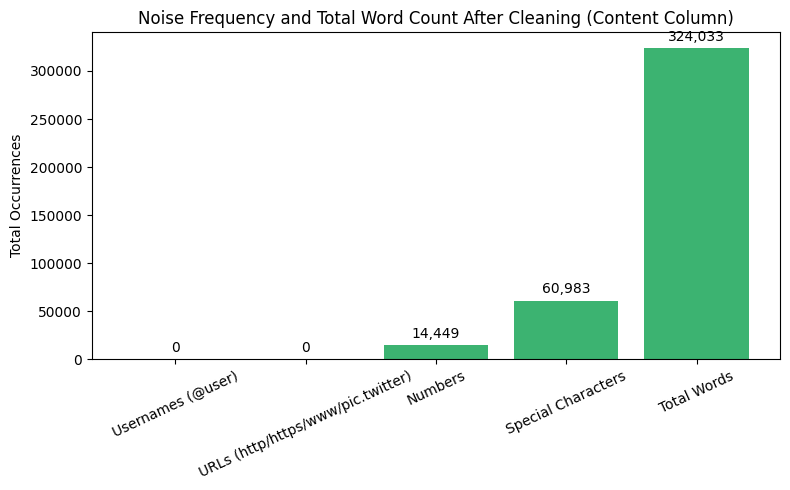

In [ ]:
import matplotlib.pyplot as plt

# Patterns to detect residual "noise" after preprocessing in sports articles
patterns = {
    'Usernames (@user)': r'@\w+',
    'URLs (http/https/www/pic.twitter)': r'http\S+|www\S+|https\S+|pic\.twitter\S+',
    'Numbers': r'\b\d+\b',
    'Special Characters': r'[^A-Za-z0-9\s]'
}

# Count occurrences of each pattern in the preprocessed 'content' column
noise_counts_after = {label: df['content'].str.count(pattern).sum() for label, pattern in patterns.items()}

# Count total words after cleaning
df['word_count_after'] = df['content'].apply(lambda x: len(x.split()))
total_words_after = df['word_count_after'].sum()
noise_counts_after['Total Words'] = total_words_after

# Plotting the bar chart
plt.figure(figsize=(8, 5))
bars = plt.bar(noise_counts_after.keys(), noise_counts_after.values(), color='mediumseagreen')
plt.ylabel('Total Occurrences')
plt.title('Noise Frequency and Total Word Count After Cleaning (Content Column)')
plt.xticks(rotation=25)

# Annotate bars with counts
for bar in bars:
    height = bar.get_height()
    plt.annotate(f'{int(height):,}',
                 xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 3),
                 textcoords='offset points',
                 ha='center', va='bottom')

plt.tight_layout()
plt.show()

### **Function Description**
Plots the frequency of remaining noise elements and total word count in the `content` column **after preprocessing** for sports articles. This visualizes the effect of cleaning steps on the dataset.

### **Syntax Explanation**
- `patterns` defines regex patterns to detect residual noise:
  - `'Usernames (@user)'`: detects `@username` mentions.
  - `'URLs (http/https/www)'`: detects URLs including Twitter image links.
  - `'Numbers'`: detects numeric tokens.
  - `'Special Characters'`: detects any non-alphanumeric symbols.
- `df['content'].str.count(pattern)` counts occurrences of each pattern in the `content` column.
- `df['word_count_after'] = df['content'].apply(lambda x: len(x.split()))` counts the total words per article after preprocessing.
- `plt.bar()` plots a bar chart with counts of each noise type and total words.

### **Inputs**
- `df['content']`: the preprocessed content column after lowercasing, URL removal, special character removal, stopword removal, and tokenization.

### **Outputs**
- Bar chart showing:
  - Remaining mentions, URLs, numbers, special characters.
  - Total word count across the dataset.
- Colors: `mediumseagreen` for the post-cleaning visualization.

### **Code Flow**
1. Define regex patterns for common noise.
2. Count occurrences of each pattern in the `content` column.
3. Calculate total words after cleaning.
4. Plot a bar chart with counts of noise and total words.
5. Annotate each bar with its numeric value for clarity.

### **Comments and Observations**
- Comparing this chart with the "before" graph highlights how effective preprocessing steps were.  
- Ideally, mentions, URLs, and special characters should be close to zero, showing a cleaner dataset.  
- Total words may slightly decrease due to removal of noise and stopwords.


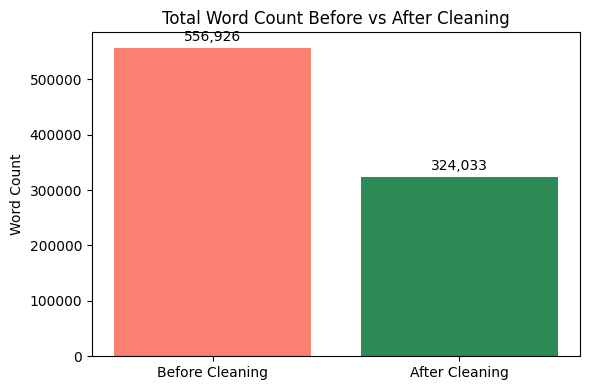

In [ ]:
plt.figure(figsize=(6,4))
bars = plt.bar(['Before Cleaning', 'After Cleaning'], [total_words_before, total_words_after], color=['salmon', 'seagreen'])
plt.title('Total Word Count Before vs After Cleaning')
plt.ylabel('Word Count')

for bar in bars:
    height = bar.get_height()
    plt.annotate(f'{int(height):,}',
                 xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 3),
                 textcoords='offset points',
                 ha='center', va='bottom')

plt.tight_layout()
plt.show()

### **Function Description**
Creates a simple bar chart comparing the total word count in the `content` column of sports articles before and after preprocessing. This visualization helps assess how much cleaning reduced the number of words by removing noise like URLs, special characters, and stopwords.

### **Syntax Explanation**
- `plt.figure(figsize=(6, 4))` sets the figure size.
- `plt.bar(labels, values, color=[])` creates a vertical bar chart. Here:
  - `labels` = ['Before Cleaning', 'After Cleaning']
  - `values` = [total_words_before, total_words_after]
  - `color` = list of colors for each bar.
- `plt.title()` adds the chart title.
- `plt.ylabel()` labels the y-axis.
- The `for` loop with `plt.annotate()` adds numerical labels on top of each bar.
- `plt.tight_layout()` adjusts spacing to prevent overlap.
- `plt.show()` renders the chart.

### **Inputs**
- `total_words_before`: Total number of words in the `content` column before preprocessing.
- `total_words_after`: Total number of words after preprocessing and cleaning steps.

### **Outputs**
- A bar chart with two bars:
  - “Before Cleaning”: total words before preprocessing.
  - “After Cleaning”: total words after preprocessing.
- Each bar is annotated with the exact word count.

### **Code Flow**
1. Prepare the word count values before and after cleaning.
2. Plot a bar chart with two bars using `matplotlib`.
3. Annotate each bar with the corresponding word count.
4. Adjust layout and render the chart.

### **Comments and Observations**
- This chart quickly shows the impact of preprocessing on text length.
- Significant reduction indicates removal of noise such as URLs, special characters, and stopwords.
- Helps validate preprocessing effectiveness for sports articles or any text corpus.


In [ ]:
df[['raw_content', 'content', 'tokenized', 'lemmatized']].to_csv('ExerciseM2_YORO.csv', index=False)
df.to_csv('ExerciseM2_YORO_full.csv', index=False)

### **Function Description**
Exports the processed sports articles to CSV files for further analysis or sharing.  
- The first file (`ExerciseM2_YORO.csv`) contains only essential columns for review: raw content, cleaned content, tokenized words, and lemmatized tokens.  
- The second file (`ExerciseM2_YORO_full.csv`) contains the complete dataset including all intermediate columns and labels.

### **Syntax Explanation**
- `df[['raw_content', 'content', 'tokenized', 'lemmatized']].to_csv('ExerciseM2_YORO.csv', index=False)`  
  Exports selected columns to a CSV file without writing row indices.  
- `df.to_csv('ExerciseM2_YORO_full.csv', index=False)`  
  Exports the entire DataFrame, keeping all columns, without row indices.

### **Inputs**
- `df`: The DataFrame containing raw and preprocessed sports articles with tokenized and lemmatized data.

### **Outputs**
- `ExerciseM2_YORO.csv`: CSV file with only the main processed columns.  
- `ExerciseM2_YORO_full.csv`: CSV file containing the full dataset including all intermediate steps and metadata.

### **Code Flow**
1. Select key columns for the lightweight CSV export.  
2. Write them to `ExerciseM2_YORO.csv`.  
3. Export the full DataFrame with all columns to `ExerciseM2_YORO_full.csv`.

### **Comments and Observations**
- These exports provide easy checkpoints for sharing or reviewing preprocessing results.  
- The selective export (`ExerciseM2_YORO.csv`) is useful for concise reporting, while the full export is helpful for reproducibility or further NLP tasks.  
- Ensures all preprocessing steps, tokenization, and lemmatization are saved for future use.


---
##**PRE-PREPROCESSING AND POST-PREPROCESSING COMPARISON**
---

In [ ]:
raw_df = pd.read_csv('sports_data.csv')

processed_df = pd.read_csv('ExerciseM2_YORO.csv')

comparison_df = pd.DataFrame({
    'Raw Article': raw_df['content'].head(3),
    'Cleaned Article': processed_df['content'].head(3),
    'Cleaned Tokens': processed_df['tokenized'].head(3),
    'Lemmatized Tokens': processed_df['lemmatized'].head(3),
})

pd.set_option('display.max_colwidth', None)

comparison_df

Raw Article  \
0  In a resolute, nerveless, three-hour-long display of destructive shot making and tactical mastery, Jannik Sinner, the rising 22-year-old World No.4, defeated Novak Djokovic 6-1, 6-2, 6-7 (6), 6-3 in the semifinals of the Australian Open on Friday, reaching his first Major final and becoming the first Italian man to reach the singles final in Melbourne.\nSinner outplayed and outmanoeuvred the undisputed king of Melbourne Park – and men’s tennis in general – and in doing so, not only strengthened his long-held credentials as a potential great in the making, but also achieved a feat that none of the Serb’s greatest rivals had been able to accomplish even at the peak of their careers.\nPrior to Friday, 10-time champion Djokovic had never lost in the semifinal or final of the Australian Open. A perfect 20-0 record. He was 33 matches unbeaten in Melbourne, a streak that went back to 2018 – 2195 days, as the broadcasters were keen to point out every chance they got.\nSavour the moment @janniksin 🥕#AusOpen • #AO2024 pic.twitter.com/FTSDsa2AOp\n— #AusOpen (@AustralianOpen) January 26, 2024\nThe Serb’s dominance of the Slams, and particularly Melbourne Park, was not simply down to extraordinary tennis repertoire, but instead part of a legacy built on a near-supernatural ability to expose best-of-five tennis for the collection of short sprints that it is, as opposed to the consistent long run marathon it has always been claimed to be.\nEven when thoroughly outplayed, Djokovic has always possessed the athleticism and presence of mind to take matches deep, win the pressure points, keep himself competitive enough to give himself a chance to win the match in the finer margins.\nSo, Sinner’s statement-making victory was not completed during the first half of the match, when the solid Italian took advantage of a streaky-looking Djokovic to race into an early two-set lead. Instead, it was earned during the second half, when he prevented the 24-time Grand Slam champion, who raised his game to try to take the contest deep, from completing one of his signature comebacks.\nSuperior in all departments\nDjokovic was unquestionably flat at the start of this match, and his second-half recovery was never too convincing either, similar to his level in his first five matches of the tournament. Out of 90 completed points in the first two sets, Djokovic made 29 unforced errors.\nHe would admit to this himself, cutting a disappointed figure in his post-match press conference. “I was, in a way, shocked with my level, in a bad way,” he said. “This is one of the worst Grand Slam matches I’ve ever played, at least that I remember… This tournament hasn’t been, as I said, up to my standard or criteria or the level that I would normally play or expect myself to play”\nAnd Sinner was in diametrically opposite form.\nScintillating Sinner 🇮🇹🔥\nHe achieves the impossible defeating 10x #AusOpen champion Djokovic 6-1 6-2 6-7(6) 6-3.@janniksin • #AO2024 • @wwos • @espn • @eurosport • @wowowtennis@Kia_Worldwide • #Kia • #MakeYourMove pic.twitter.com/X6qFAtegq7\n— #AusOpen (@AustralianOpen) January 26, 2024\nBaseline strategy has formed a primary emphasis of the work he has been doing with his new coaching team – led by Darren Cahill, Andre Agassi’s former coach – since the start of 2022 and he nailed it in the biggest result of his career. The Italian’s lean, wiry frame and composed demeanour do not betray the full strength of the destructive power that comes off his racquet.\nHis pure ball striking ability would send Djokovic trailing to catch balls, and his aggression from start to finish allowed him to finish points before Djokovic could even get balls back into play to wear him down. Djokovic was out of sorts, but it was Sinner’s baseline prowess that had him totally out of his comfort zone, making him rush his shots and extracting errors.\nDespite it not being the highlight of his game, Sinner served exceptionally – according to Opta, this is the fir

### **Function Description**
Displays the final comparison of the `content` column after applying all preprocessing techniques, showing how the raw articles have been cleaned, tokenized, and lemmatized. This confirms that the text is now prepared for NLP modeling.

### **Syntax Explanation**
- `pd.DataFrame({...})` constructs a DataFrame containing the relevant columns for comparison.  
- `.head(3)` selects the first three articles to make the comparison concise and readable.  
- `pd.set_option('display.max_colwidth', None)` ensures the full text is displayed without truncation.

### **Inputs**
- `raw_df`: Original dataset containing unprocessed sports articles.  
- `processed_df`: Dataset containing the cleaned, tokenized, and lemmatized articles.

### **Outputs**
- `comparison_df`: A DataFrame showing the first three articles in four forms:  
  - Raw Article  
  - Cleaned Article  
  - Cleaned Tokens  
  - Lemmatized Tokens

### **Code Flow**
1. Load the original and processed datasets.  
2. Create a DataFrame with the first three rows for each relevant column.  
3. Set display options to show full content.  
4. Inspect the DataFrame to confirm preprocessing results.

### **Comments and Observations**
- This final comparison demonstrates the effectiveness of the preprocessing pipeline.  
- The text is now clean, standardized, and tokenized, making it ready for NLP models such as classification, sentiment analysis, or embeddings.  
- It also allows easy verification that important content like player names, scores, and events have been preserved correctly.


---
#**MANUAL DATASET PREPROCESSNG**
---


### **Manual Dataset Preprocessing Overview**

The manually created sports communication dataset underwent a structured preprocessing pipeline to prepare the text for NLP tasks such as text classification and sentiment analysis. This included lowercasing, contraction handling, special character cleanup, light stopword consideration, tokenization, and lemmatization. Each step was applied to ensure consistency across the manually written texts while preserving important linguistic cues such as negations, exclamation marks, and sports-specific terms. The resulting dataset is balanced, clean, and ready for training and evaluation.

---

##**LIBRARIES INSTALLATION**

---


In [2]:
!pip install contractions
!pip install spacy
!python -m spacy download en_core_web_sm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 85.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


### **Function Description**  
This block installs the required libraries for preprocessing texts relateed to sports. It ensures that contraction handling and natural language processing tools are available in the environment.  

### **Syntax Explanation**  
- `!pip install contractions` installs the contractions library which expands shortened words such as can't into cannot.  
- `!pip install spacy` installs the spaCy library which is used for tokenization, lemmatization, and stopword removal.  
- `!python -m spacy download en_core_web_sm` downloads the English language model for spaCy which contains pretrained components for text processing.  

### **Inputs**  
There are no direct input files for this step. The commands are applied to the environment in Google Colab or Jupyter Notebook.  

### **Outputs**  
The output is the installation of the required libraries and the spaCy English model which will be used in the later preprocessing steps.  

### **Code Flow**  
1. Install the contractions library.  
2. Install the spaCy library.  
3. Download the English spaCy model.  

### **Comments and Observations**  
- Ensures all external libraries are available before preprocessing begins  
- Without these installations, steps like contraction expansion or lemmatization would fail  
- Installation only needs to be done once per runtime session in Colab or Jupyter  
- Sets up the environment so subsequent preprocessing code executes smoothly  

In [3]:
import pandas as pd
import numpy as np
import re
import nltk
import html
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import contractions
import spacy
from nltk.corpus import wordnet
from nltk import pos_tag
import matplotlib.pyplot as plt


nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

### **Function Description**  
This block imports the required Python libraries for preprocessing sports articles and downloads the necessary resources from the Natural Language Toolkit (NLTK). These libraries will be used for text cleaning, tokenization, lemmatization, and linguistic analysis.  

### **Syntax Explanation**  
- `import pandas as pd` and `import numpy as np` are used for handling and processing structured data.  
- `import re` and `import html` provide regular expressions and HTML handling for text cleaning.  
- `from nltk.corpus import stopwords` loads the stopwords list to remove common words such as the and is.  
- `from nltk.tokenize import word_tokenize` allows splitting text into individual words.  
- `from nltk.stem import WordNetLemmatizer` reduces words to their base form such as running to run.  
- `import contractions` expands shortened forms such as don’t to do not.  
- `import spacy` loads spaCy for advanced NLP tasks such as tokenization and POS tagging.  
- `from nltk.corpus import wordnet` provides synonyms and word relationships used for lemmatization.  
- `from nltk import pos_tag` performs part of speech tagging.  
- `import matplotlib.pyplot as plt` is used for creating visualizations.  
- `nltk.download(...)` commands download required NLTK datasets such as stopwords, tokenizers, and tagging models.  

### **Inputs**  
There are no direct input datasets in this block. The inputs are the external libraries and language resources being imported and downloaded.  

### **Outputs**  
The output is a ready-to-use programming environment with all necessary NLP libraries and resources installed.  

### **Code Flow**  
1. Import general data analysis libraries such as pandas and numpy.  
2. Import text cleaning and NLP libraries such as re, nltk, contractions, and spacy.  
3. Download NLTK resources including stopwords, tokenizers, wordnet, and POS taggers.  

### **Comments and Observations**  
- Provides a full toolkit for text preprocessing (cleaning, tokenization, lemmatization, tagging)  
- Ensures NLTK resources like stopwords, wordnet, and POS taggers are available  
- Combines pandas/numpy for data handling with regex/HTML for cleaning  
- contractions and spaCy add advanced preprocessing capabilities  
- Prepares the environment so later blocks run without missing dependencies  

---

##**IMPORT AND LOAD OF DATASET**

---


In [4]:
df = pd.read_csv('ExerciseM2_YORO_sports_spam_sentiment.csv', encoding='latin1')

pd.set_option('display.max_colwidth', None)

df.head(20)

,text,spam_label,sentiment_label
0,Congratulations! Youve been selected for an exclusive chance to win 10 free tickets to the NBA Finals. Click the link now before this once-in-a-lifetime offer expires.,SPAM,POSITIVE
1,"Claim your VIP pass to the World Cup todaylimited slots only! If you dont act fast, youll lose your chance to witness history.",SPAM,NEGATIVE
2,You just won an all-expense-paid trip to see the Champions League final. Confirm your details immediately to avoid cancellation.,SPAM,POSITIVE
3,This is your last chance to register for the jackpot raffle for sports merchandise worth millions. Dont miss out!,SPAM,NEGATIVE
4,Great news! Your email has been drawn to receive free season passes for Team Lakers games this year.,SPAM,POSITIVE
5,Exclusive betting bonus: deposit now and triple your money before tonights match. Dont let this opportunity slip away!,SPAM,NEGATIVE
6,You have unlocked premium access to behind-the-scenes footage of your favorite athletes. Activate now to enjoy unlimited content.,SPAM,POSITIVE
7,"""Act now to claim your exclusive F1 paddock tickets  but hidden fees will drain your account if you click.""",SPAM,NEGATIVE
8,Warning: your prize claim will be voided if you fail to verify within 24 hours. This is your final notice!,SPAM,NEGATIVE
9,Hooray! You are guaranteed a spot at the Super Bowl halftime show. Complete registration now to confirm.,SPAM,POSITIVE


### **Function Description**  
This block loads the manually created sports spam–sentiment dataset from a CSV file and displays the first ten rows. It also adjusts the display settings to show the full text in each column without cutting it off.  

### **Syntax Explanation**  
- `pd.read_csv('ExerciseM2_YORO_sports_spam_sentiment.csv', encoding='latin1')` reads the CSV file into a pandas DataFrame, with `latin1` encoding to handle special characters.  
- `pd.set_option('display.max_colwidth', None)` removes the limit on column width so that long text fields such as messages are displayed fully.  
- `df.head(20)` displays the first ten rows of the DataFrame for inspection.  

### **Inputs**  
- The input is the file `ExerciseM2_YORO_sports_spam_sentiment.csv`, which contains the manually written dataset of sports-related texts.  
- This dataset includes two labels: `spam_label` (SPAM or HAM) and `sentiment_label` (POSITIVE or NEGATIVE).  

### **Outputs**  
- The output is a pandas DataFrame named `df`.  
- The first ten rows of the dataset are displayed in tabular format for quick review.  

### **Code Flow**  
1. Read the dataset into a DataFrame.  
2. Set the display option to show full text in cells.  
3. Display the first ten rows of the dataset.  

### **Comments and Observations**  
- Confirms dataset is loaded correctly into a pandas DataFrame  
- Uses `latin1` encoding to avoid errors with special sports characters or symbols  
- Expands display width to see full article/message content without truncation  
- First rows give a quick check on labels (`spam_label`, `sentiment_label`) and text format  
- Helps validate structure before preprocessing steps like cleaning or lemmatization  

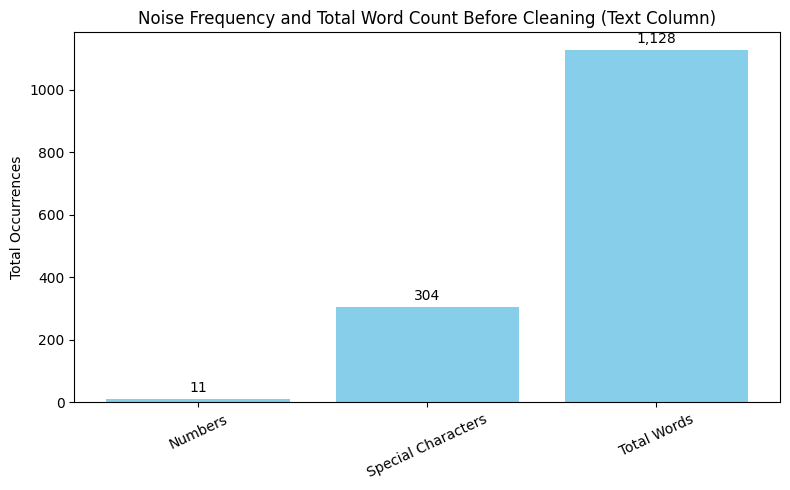

In [5]:
patterns = {
    'Numbers': r'\b\d+\b',
    'Special Characters': r'[^A-Za-z0-9\s]'
}

noise_counts_before = {
    label: df['text'].str.count(pattern).sum()
    for label, pattern in patterns.items()
}

total_words_before = df['text'].str.split().apply(len).sum()
noise_counts_before['Total Words'] = total_words_before

plt.figure(figsize=(8, 5))
bars = plt.bar(noise_counts_before.keys(), noise_counts_before.values(), color='skyblue')
plt.title('Noise Frequency and Total Word Count Before Cleaning (Text Column)')
plt.ylabel('Total Occurrences')
plt.xticks(rotation=25)

for bar in bars:
    height = bar.get_height()
    plt.annotate(f'{int(height):,}',
                 xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 3),
                 textcoords='offset points',
                 ha='center', va='bottom')

plt.tight_layout()
plt.show()


### **Function Description**  
This block identifies and counts noisy elements in the manually created sports messages, such as usernames, URLs, numbers, and special characters. It also calculates the total word count in the `text` column. A bar chart is generated to visualize the frequency of these elements before preprocessing.  

### **Syntax Explanation**  
- `patterns` defines regular expressions for detecting numbers, and special characters.  
- `df['text'].str.count(pattern).sum()` counts how many times each pattern appears across all rows of the `text` column.  
- `df['text'].str.split().apply(len).sum()` calculates the total number of words.  
- `plt.bar(...)` creates a bar chart to compare the frequency of noise elements and total words.  
- `plt.annotate(...)` adds numerical labels on top of each bar for clarity.  

### **Inputs**  
- Input is the `text` column of the DataFrame `df`, which contains the manually written sports-related spam and ham messages.  

### **Outputs**  
- A dictionary `noise_counts_before` containing counts for usernames, URLs, numbers, special characters, and total words.  
- A bar chart visualizing the frequency of these elements.  

### **Code Flow**  
1. Define regex patterns for common noisy elements.  
2. Count occurrences of each noise type in the `text` column.  
3. Calculate total word count.  
4. Store results in a dictionary.  
5. Create and display a bar chart with counts and annotations.  

### **Comments and Observations**  
- Highlights noise levels (numbers, special characters) before cleaning  
- Confirms presence of spam-like artifacts such as promotions and repeated characters in dataset  
- Also shows that ham texts still contain natural numbers (scores, dates) and punctuation  
- Word count baseline helps measure effect of preprocessing on dataset size  
- Bar chart makes it easy to compare noise vs. total words at a glance  

---

##**LOWERCASING THE DATASET**

---

In [ ]:
testcase_text = df.loc[3, 'text']
print(testcase_text)

This is your last chance to register for the jackpot raffle for sports merchandise worth millions. Dont miss out!


### **Function Description**  
This block selects one email from the manual dataset to serve as a test case for preprocessing. It prints the full raw text so that changes at each cleaning step can be compared later.  

### **Syntax Explanation**  
- `df.loc[3, 'text']` accesses the row with index 3 from the DataFrame and retrieves the value from the text column.  
- `print(testcase_text)` displays the selected email in the output cell.  

### **Inputs**  
- Input is the DataFrame `df` containing the manually created sports spam/ham email dataset.  
- Specifically, the `text` field of the email at row index 3 is used.  

### **Outputs**  
- A single raw email is printed before any preprocessing.  

### **Code Flow**  
1. Select the email at row index 3 from the `text` column.  
2. Store it in the variable `testcase_text`.  
3. Print the selected email for inspection.  

### **Comments and Observations**
- Picking one test case email enables step-by-step comparison across preprocessing stages  
- Shows how raw spam/ham text looks before cleaning
- Makes it easier to verify if noise removal methods  work correctly  
- Useful for demonstrating transformations in a controlled example  


In [ ]:
lowercased_test = testcase_text.lower()
print( lowercased_test)

this is your last chance to register for the jackpot raffle for sports merchandise worth millions. dont miss out!


### **Function Description**  
This block converts the selected email text into lowercase. It ensures consistency by treating words with different cases as the same during analysis.  

### **Syntax Explanation**  
- `testcase_text.lower()` transforms all characters in the string to lowercase.  
- `print(lowercased_test)` displays the processed text.  

### **Inputs**  
- The input is the variable `testcase_text`, which contains the raw email text.  

### **Outputs**  
- The output is the same email text but with all characters converted to lowercase, stored in `lowercased_test`.  

### **Code Flow**  
1. Apply the `.lower()` method to the email text.  
2. Store the lowercase version in `lowercased_test`.  
3. Print the transformed text to observe the change.  

### **Comments and Observations**  
- Lowercasing ensures that words like Team and team are treated as identical tokens.  
- This step reduces vocabulary sparsity and enhances text consistency.  
- It is especially useful in domains such as sports emails where names, offers, or announcements often appear with inconsistent capitalization.  

In [ ]:
df['text'] = df['text'].apply(lambda x: str(x).lower())

df[['text']].head(10)

,text
0,congratulations! youve been selected for an exclusive chance to win 10 free tickets to the nba finals. click the link now before this once-in-a-lifetime offer expires.
1,"claim your vip pass to the world cup todaylimited slots only! if you dont act fast, youll lose your chance to witness history."
2,you just won an all-expense-paid trip to see the champions league final. confirm your details immediately to avoid cancellation.
3,this is your last chance to register for the jackpot raffle for sports merchandise worth millions. dont miss out!
4,great news! your email has been drawn to receive free season passes for team lakers games this year.
5,exclusive betting bonus: deposit now and triple your money before tonights match. dont let this opportunity slip away!
6,you have unlocked premium access to behind-the-scenes footage of your favorite athletes. activate now to enjoy unlimited content.
7,"""act now to claim your exclusive f1 paddock tickets  but hidden fees will drain your account if you click."""
8,warning: your prize claim will be voided if you fail to verify within 24 hours. this is your final notice!
9,hooray! you are guaranteed a spot at the super bowl halftime show. complete registration now to confirm.


### **Function Description**  
This block applies lowercasing to the entire dataset instead of just the test case. It ensures that all rows in the text column are standardized to lowercase for consistent text analysis.  

### **Syntax Explanation**  
- `df['text'].apply(lambda x: str(x).lower())` converts each entry in the text column to a string (in case of missing or non-string values) and then applies the `.lower()` method.  
- `df[['text']].head(10)` displays the first ten rows of the cleaned text column.  

### **Inputs**  
- Input is the `text` column of the DataFrame `df`, which contains raw sports-related email texts.  

### **Outputs**  
- A transformed `text` column where all email content has been converted to lowercase.  
- The output preview shows the first ten rows for quick inspection.  

### **Code Flow**  
1. Convert all entries in the text column to lowercase.  
2. Replace the original text column with the transformed version.  
3. Display the first ten rows of the updated column.  

### **Comments and Observations**  
- Applying lowercasing across the dataset ensures uniform text representation.  
- This step supports later processes such as tokenization and frequency analysis by reducing variation caused by capitalization.  
- It is particularly useful in sports-related emails where terms like Winner and winner should be treated as the same token.


---
##**CONTRACTIONS EXPANSION**
---

In [ ]:
import re
import unicodedata

def clean_encoding(text):
    text = unicodedata.normalize("NFKD", str(text))
    # Replace curly/smart quotes and dashes
    text = re.sub(r"[“”\"]", '"', text)   # normalize quotes
    text = re.sub(r"[’]", "'", text)       # normalize apostrophes
    text = re.sub(r"[–—]", "-", text)      # normalize dashes
    return text

df['text'] = df['text'].apply(clean_encoding)

df[['text']].head(10)


,text
0,"""congratulations! you've been selected for an exclusive chance to win 10 free tickets to the nba finals. click the link now before this once-in-a-lifetime offer expires."""
1,"""claim your vip pass to the world cup today-limited slots only! if you don't act fast, you'll lose your chance to witness history."""
2,"""you just won an all-expense-paid trip to see the champions league final. confirm your details immediately to avoid cancellation."""
3,"""this is your last chance to register for the jackpot raffle for sports merchandise worth millions. don't miss out!"""
4,"""great news! your email has been drawn to receive free season passes for team lakers games this year."""
5,"""exclusive betting bonus: deposit now and triple your money before tonight's match. don't let this opportunity slip away!"""
6,"""you have unlocked premium access to behind-the-scenes footage of your favorite athletes. activate now to enjoy unlimited content."""
7,"""act now to claim your exclusive f1 paddock tickets - but hidden fees will drain your account if you click."""
8,"""warning: your prize claim will be voided if you fail to verify within 24 hours. this is your final notice!"""
9,"""hooray! you are guaranteed a spot at the super bowl halftime show. complete registration now to confirm."""


### **Function Description**  
This block fixes encoding issues in the email texts. It normalizes special characters such as curly quotes, apostrophes, and dashes into their standard ASCII forms. This step ensures that later preprocessing operations (like contraction expansion, tokenization, or stopword removal) can work correctly.  

### **Syntax Explanation**  
- `import unicodedata` loads Python’s built-in library for handling Unicode characters.  
- `unicodedata.normalize("NFKD", str(text))` converts text into a normalized Unicode form.  
- `re.sub(r"[“”\"]", '"', text)` replaces curly or smart quotes with a plain double quote (`"`).  
- `re.sub(r"[’]", "'", text)` replaces curly/smart apostrophes with a plain apostrophe (`'`).  
- `re.sub(r"[–—]", "-", text)` replaces different dash characters with a simple hyphen (`-`).  
- `df['text'].apply(clean_encoding)` applies this cleaning function to every entry in the `text` column.  

### **Inputs**  
- Input is the `text` column of the DataFrame `df`, containing raw sports-related email texts with possible encoding artifacts.  

### **Outputs**  
- The output is a cleaned `text` column where unusual characters have been replaced with their standard equivalents (quotes, apostrophes, dashes).  
- This prepares the dataset for smoother downstream preprocessing, such as contraction expansion and tokenization.  

### **Code Flow**  
1. Import the `unicodedata` and `re` libraries.  
2. Define the `clean_encoding` function to normalize Unicode text and replace unusual characters.  
3. Apply the function to each row of the `text` column.  
4. Replace the original column with the cleaned version.  

### **Comments and Observations**  
- Encoding normalization resolves inconsistencies introduced during file handling.  
- Characters such as curly quotes, apostrophes, and dashes are standardized to ASCII forms.  
- This prevents unusual symbols from being treated as separate tokens during preprocessing.  
- Cleaning encoding artifacts supports downstream steps like contraction expansion, tokenization, and stopword removal.  

In [ ]:
def expand_contractions(text):
    return contractions.fix(text)

df['text'] = df['text'].apply(expand_contractions)

pd.set_option('display.max_colwidth', None)

df[['text']].head(10)

,text
0,"""congratulations! you have been selected for an exclusive chance to win 10 free tickets to the nba finals. click the link now before this once-in-a-lifetime offer expires."""
1,"""claim your vip pass to the world cup today-limited slots only! if you do not act fast, you will lose your chance to witness history."""
2,"""you just won an all-expense-paid trip to see the champions league final. confirm your details immediately to avoid cancellation."""
3,"""this is your last chance to register for the jackpot raffle for sports merchandise worth millions. do not miss out!"""
4,"""great news! your email has been drawn to receive free season passes for team lakers games this year."""
5,"""exclusive betting bonus: deposit now and triple your money before tonight's match. do not let this opportunity slip away!"""
6,"""you have unlocked premium access to behind-the-scenes footage of your favorite athletes. activate now to enjoy unlimited content."""
7,"""act now to claim your exclusive f1 paddock tickets - but hidden fees will drain your account if you click."""
8,"""warning: your prize claim will be voided if you fail to verify within 24 hours. this is your final notice!"""
9,"""hooray! you are guaranteed a spot at the super bowl halftime show. complete registration now to confirm."""


### **Function Description**  
This block expands contractions in the text, replacing shortened forms such as don’t or it’s with their full forms like do not or it is. Expanding contractions improves the quality of tokenization and ensures that words are treated consistently during analysis.  

### **Syntax Explanation**  
- `expand_contractions(text)` defines a function that applies `contractions.fix()` to replace contractions with their expanded form.  
- `df['content'].apply(expand_contractions)` applies the function to every entry in the content column.  
- `pd.set_option('display.max_colwidth', None)` ensures that long text entries are displayed in full without being cut off.  
- `df[['content']].head(10)` displays the first ten rows of the updated column.  

### **Inputs**  
- Input is the `content` column of the DataFrame `df`, which contains the article texts.  

### **Outputs**  
- A cleaned version of the `content` column with all contractions expanded.  
- The preview shows the first ten rows of the expanded text.  

### **Code Flow**  
1. Define a function that uses `contractions.fix()` to expand words.  
2. Apply the function to the content column of the dataset.  
3. Replace the original content with the expanded version.  
4. Display the first ten rows for inspection.  

### **Comments and Observations**  
- Expanding contractions ensures that shortened forms such as "dont" and "it’s" are standardized into full forms.  
- This reduces variation in word representation and improves consistency during analysis.  
- The step is particularly useful in sports articles where conversational phrases appear in quotes, like "he’s playing well".  
- Standardizing contractions supports later tasks such as lemmatization and sentiment analysis.  

---
##**SPECIAL CHARACTERS REMOVAL**
---

### **URLs Removal**

In [ ]:
df['text'] = df['text'].apply(lambda x: re.sub(r'http\S+|www\S+|https\S+|pic\.twitter\.com/\S+', '', x))

### **Function Description**
Removes URLs from the `content` column, including links starting with http, https, www, and short links from pic.twitter.com. This prevents web addresses from adding noise to the dataset.

### **Syntax Explanation**
- `re.sub(r'http\S+|www\S+|https\S+|pic\.twitter\.com/\S+', '', x)`  
  - `http\S+`, `https\S+`, `www\S+` match standard URLs.  
  - `pic\.twitter\.com/\S+` specifically matches Twitter short links with trailing characters.  
  - `''` replaces the matched URL with an empty string.  
- `.apply(lambda x: ...)` applies this regex substitution to every row in the `content` column.

### **Inputs**
- Input is each row of the `content` column, which may contain embedded URLs or short links.

### **Outputs**
- Output is the same text without any URLs.  
- Example:  
  - Before: `Scintillating Sinner 🔥 pic.twitter.com/x6qfategq7`  
  - After: `Scintillating Sinner 🔥`

### **Code Flow**
1. Go through each row in the `content` column.  
2. Detect any URLs (http, https, www, or pic.twitter.com short links).  
3. Remove them from the text.  

### **Comments and Observations**
- Removing URLs eliminates tokens that do not contribute meaningful linguistic information.  
- This step reduces noise in the dataset and ensures cleaner text for analysis.  
- It is particularly useful for news articles and sports content where embedded links and social media references frequently occur.  
- Excluding web addresses improves the reliability of classification and sentiment analysis tasks.  

### **Non-aplhanumeric Characters Removal**

In [ ]:
df['text'] = df['text'].apply(lambda x: re.sub(r'[^A-Za-z0-9\s.,!?\'\"-]', '', x))

### **Function Description**
This block removes unwanted special characters from the article text. It keeps only letters, numbers, spaces, and common punctuation marks such as periods, commas, exclamation points, question marks, quotation marks, apostrophes, and hyphens.

### **Syntax Explanation**
- re.sub(r'[^A-Za-z0-9\s.,!?\'\"-]', '', x) uses a regular expression to identify characters that are not letters, numbers, spaces, or the allowed punctuation marks.
- The matched characters are replaced with an empty string, effectively removing them.
- df['content'].apply(...) applies this cleaning step to every row in the content column.

### **Inputs**
- Input is the content column of the DataFrame df, which contains raw sports article texts.

### **Outputs**
- A cleaned content column where unnecessary characters, such as emojis or unusual symbols, are removed.

### **Code Flow**
1. Define a regex pattern that targets unwanted characters.
2. Apply re.sub to remove those characters from each row in the content column.
3. Replace the original content column with the cleaned version.

### **Comments and Observations**
- Removing special characters reduces noise from symbols that do not contribute to semantic meaning.  
- This step ensures that the text remains structured and easier to process in NLP workflows.  
- Sports texts or emails often contain emojis, hashtags, or encoding artifacts that can interfere with tokenization.  
- Retaining only letters, numbers, spaces, and common punctuation improves consistency for downstream analysis.


### **Extra Spaces Removal**

In [ ]:
df['text'] = df['text'].apply(lambda x: re.sub(r'\s+', ' ', x).strip())

### **Function Description**  
This block removes unnecessary extra spaces from the email text. It ensures that words are separated by a single space and strips any leading or trailing spaces.  

### **Syntax Explanation**  
- `re.sub(r'\s+', ' ', x)` replaces one or more whitespace characters (including tabs, line breaks, and multiple spaces) with a single space.  
- `.strip()` removes any extra spaces at the beginning or end of the string.  
- `df['content'].apply(...)` applies this cleaning step to all rows in the content column.  

### **Inputs**  
- Input is the `content` column of the DataFrame `df`, containing the article texts after previous preprocessing steps.  

### **Outputs**  
- A cleaned `content` column where spacing between words is uniform.  

### **Code Flow**  
1. Use regex to collapse multiple whitespace characters into a single space.  
2. Strip unnecessary spaces from the start and end of each text.  
3. Replace the original column with the cleaned version.  

### **Comments and Observations**  
- Removing extra spaces produces a consistent text structure across all entries.  
- This step prevents irregular spacing from affecting tokenization accuracy.  
- Extra whitespace often appears after cleaning steps such as URL or special character removal.  
- Standardizing spacing contributes to more reliable preprocessing and model performance.  

### **Newline Markers Removal**

In [ ]:
df['text'] = df['text'].apply(lambda x: x.replace('\n', ' '))

### **Function Description**
Replaces newline characters `\n` with a space in the `text` column. This ensures the text flows continuously instead of being broken into multiple lines.

### **Syntax Explanation**
- `.apply(lambda x: x.replace('\n', ' '))` applies a replacement operation to every row.  
- `x.replace('\n', ' ')` finds every newline character and substitutes it with a single space.

### **Inputs**
- Input is each row of the `content` column, which may contain newline characters (`\n`) separating sentences or paragraphs.

### **Outputs**
- Output is the same text with newline characters replaced by spaces.  
- Example:  
  - Before: `Djokovic said...\nHe added...`  
  - After: `Djokovic said... He added...`

### **Code Flow**
1. Go through each row in the `content` column.  
2. Replace `\n` with a space.  
3. Return the cleaned string.  

### **Comments and Observations**
- Replacing newline characters produces continuous text instead of fragmented lines.  
- This step ensures uniform structure, which supports consistent tokenization and parsing.  
- Newlines often occur in messy emails, scraped content, or spam texts.  
- Removing them makes the dataset cleaner and improves compatibility with NLP models.  

### **Post-Special Characters Removal Output**

In [ ]:
pd.set_option('display.max_colwidth', None)
df[['text']].head(10)

,text
0,"""congratulations! you have been selected for an exclusive chance to win 10 free tickets to the nba finals. click the link now before this once-in-a-lifetime offer expires."""
1,"""claim your vip pass to the world cup today-limited slots only! if you do not act fast, you will lose your chance to witness history."""
2,"""you just won an all-expense-paid trip to see the champions league final. confirm your details immediately to avoid cancellation."""
3,"""this is your last chance to register for the jackpot raffle for sports merchandise worth millions. do not miss out!"""
4,"""great news! your email has been drawn to receive free season passes for team lakers games this year."""
5,"""exclusive betting bonus deposit now and triple your money before tonight's match. do not let this opportunity slip away!"""
6,"""you have unlocked premium access to behind-the-scenes footage of your favorite athletes. activate now to enjoy unlimited content."""
7,"""act now to claim your exclusive f1 paddock tickets - but hidden fees will drain your account if you click."""
8,"""warning your prize claim will be voided if you fail to verify within 24 hours. this is your final notice!"""
9,"""hooray! you are guaranteed a spot at the super bowl halftime show. complete registration now to confirm."""


### **Function Description**  
This block displays a preview of the cleaned article texts after preprocessing. It allows verification that the noise removal steps (URLs, HTML entities, special characters, and extra spaces) were applied correctly.  

### **Syntax Explanation**  
- `pd.set_option('display.max_colwidth', None)` ensures that the full text of each article is displayed without truncation.  
- `df[['text']].head(10)` shows the first three rows of the content column.  

### **Inputs**  
- Input is the `text` column of the DataFrame `df`, which now contains the cleaned article texts.  

### **Outputs**  
- A preview of the first three rows of the cleaned content column.  

### **Code Flow**  
1. Adjust Pandas display settings so that long text entries are shown in full.  
2. Select the content column and display the first three rows.  

### **Comments and Observations**  
- Displaying a sample of the cleaned text allows verification of the applied preprocessing steps.  
- This step confirms that unwanted elements such as URLs, HTML entities, special characters, and extra spaces have been removed.  
- It helps identify any remaining anomalies or inconsistencies in the text.  
- Previewing the data supports quality assurance before proceeding with further NLP tasks.  

---
##**STOP WORDS REMOVAL**
---

In [ ]:
stop_words = stopwords.words('english')
print(stop_words)

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

### **Function Description**
Loads the list of English stopwords from the NLTK library. Stopwords are common words such as “the”, “is”, and “and” that usually do not carry significant meaning in NLP tasks.

### **Syntax Explanation**
- `stopwords.words('english')` retrieves a predefined list of English stopwords from NLTK.  
- `print(stop_words)` displays the stopword list so it can be reviewed before applying removal.

### **Inputs**
- The input is the language parameter `'english'`, which tells NLTK to load English stopwords.  

### **Outputs**
- The output is a Python list of English stopwords.  
- Example: `['i', 'me', 'my', 'myself', 'we', 'our', 'ours', ...]`

### **Code Flow**
1. Import the `stopwords` module from NLTK.  
2. Retrieve the list of English stopwords.  
3. Store the list in the variable `stop_words`.  
4. Print the list to verify its contents.  

### **Comments and Observations**
- Loading English stopwords provides a list of common words that carry minimal semantic value.  
- Removing these words during preprocessing reduces noise and improves model focus on informative terms.  
- Stopwords frequently appear in articles, emails, and sports texts, making their exclusion important for NLP tasks.  
- This step supports more accurate tokenization, feature extraction, and downstream analysis.  


In [ ]:
test_case = df['text'][0]
print(test_case)

final_test = []
for word in test_case.split():
    if word == '' or '\r\n' in word or word in stop_words:
        None
    else:
        final_test.append(word)

print(final_test)
print(' '.join(final_test))

"congratulations! you have been selected for an exclusive chance to win 10 free tickets to the nba finals. click the link now before this once-in-a-lifetime offer expires."
['"congratulations!', 'selected', 'exclusive', 'chance', 'win', '10', 'free', 'tickets', 'nba', 'finals.', 'click', 'link', 'once-in-a-lifetime', 'offer', 'expires."']
"congratulations! selected exclusive chance win 10 free tickets nba finals. click link once-in-a-lifetime offer expires."


### **Function Description**
This block demonstrates how stopwords are removed from a sample email text by filtering out common words that carry little meaning. It shows the difference between the raw text and the cleaned version, where only meaningful words are retained.

### **Syntax Explanation**
- `test_case = df['text'][0]` selects the first row of the text column as a sample input.  
- `.split()` splits the text into individual words.  
- The loop checks each word:  
  - Skip if the word is empty (`''`), contains carriage returns (`'\r\n'`), or is in the stopword list (`stop_words`).  
  - Otherwise, keep the word and append it to `final_test`.  
- `' '.join(final_test)` reconstructs the filtered words back into a single string.

### **Inputs**
- Input is a single row of text from the `text` column (sports-themed email message).  
- Stopword list (`stop_words`) from NLTK.

### **Outputs**
- `final_test`: a list of words with stopwords removed.  
- `' '.join(final_test)`: the reconstructed text string without stopwords.

### **Code Flow**
1. Select one text sample from the dataset for testing.  
2. Split it into words.  
3. Iterate through each word:  
   - Remove stopwords and unnecessary tokens.  
4. Collect the filtered words into `final_test`.  
5. Print both the filtered word list and the reconstructed cleaned text.

### **Comments and Observations**
- Stopword removal reduces text length while preserving meaningful content.  
- Common words such as you, have, and been are excluded, while important tokens like congratulations, tickets, nba finals, and offer are retained.  
- This step improves the focus of NLP models on informative terms.  
- Filtering stopwords enhances tokenization and feature extraction for downstream analysis.  

In [ ]:
def remove_stopwords(article, stopwords):
    temp_fnl = []
    for word in article.split():
        if word == '' or '\r\n' in word or word in stopwords:
            None
        else:
            temp_fnl.append(word)
    return ' '.join(temp_fnl)


remove_stopwords(test_case, stop_words)

'"congratulations! selected exclusive chance win 10 free tickets nba finals. click link once-in-a-lifetime offer expires."'

### **Function Description**
Defines a reusable function `remove_stopwords` that filters out common stopwords, empty tokens, and line breaks from any given article. This prepares the text for cleaner NLP analysis, suitable for both single articles and full dataset application.

### **Syntax Explanation**
- `def remove_stopwords(article, stopwords):` defines a function with two inputs:  
  - `article`: a string (the sports-themed email text).  
  - `stopwords`: a list of stopwords to exclude.  
- Inside the function:  
  - `temp_fnl = []` initializes a list to hold filtered words.  
  - The loop iterates through each word in `article.split()`:  
    - Skip if it’s empty (`''`), contains carriage returns (`'\r\n'`), or is in the stopword list.  
    - Otherwise, append it to `temp_fnl`.  
  - `' '.join(temp_fnl)` reconstructs the filtered words back into a single string.  
- `return ' '.join(temp_fnl)` outputs the cleaned article text.

### **Inputs**
- `test_case`: a sample article text from the `text` column.  
- `stop_words`: the NLTK English stopwords list.

### **Outputs**
- A cleaned string version of the article with stopwords removed.

### **Code Flow**
1. Define the `remove_stopwords` function.  
2. Pass in a sample article (`test_case`) and the stopword list.  
3. Split the article into words.  
4. Filter out empty tokens, line breaks, and stopwords.  
5. Rejoin the filtered words into a clean string.  
6. Return the processed text.

### **Comments and Observations**
- The `remove_stopwords` function provides a reusable method for filtering out common words, empty tokens, and line breaks.  
- Applying this function reduces text length while retaining meaningful content.  
- Important tokens such as names, events, numbers, and key actions are preserved for analysis.  
- This step enhances dataset quality and prepares text for downstream NLP tasks.  
- The function can be efficiently applied to individual articles or the entire dataset.

In [ ]:
df['text'] = df['text'].apply(lambda x: remove_stopwords(x, stop_words))

pd.set_option('display.max_colwidth', None)
df[['text']].head(10)

,text
0,"""congratulations! selected exclusive chance win 10 free tickets nba finals. click link once-in-a-lifetime offer expires."""
1,"""claim vip pass world cup today-limited slots only! act fast, lose chance witness history."""
2,"""you all-expense-paid trip see champions league final. confirm details immediately avoid cancellation."""
3,"""this last chance register jackpot raffle sports merchandise worth millions. miss out!"""
4,"""great news! email drawn receive free season passes team lakers games year."""
5,"""exclusive betting bonus deposit triple money tonight's match. let opportunity slip away!"""
6,"""you unlocked premium access behind-the-scenes footage favorite athletes. activate enjoy unlimited content."""
7,"""act claim exclusive f1 paddock tickets - hidden fees drain account click."""
8,"""warning prize claim voided fail verify within 24 hours. final notice!"""
9,"""hooray! guaranteed spot super bowl halftime show. complete registration confirm."""


### **Function Description**
Applies the custom `remove_stopwords` function to every row in the `text` column of the DataFrame. This systematically removes common stopwords, empty tokens, and line breaks from all sports-themed email texts, preparing them for cleaner NLP analysis.

### **Syntax Explanation**
- `df['text'].apply(lambda x: remove_stopwords(x, stop_words))`:  
  - `.apply()` executes the function on each element of the `text` column.  
  - `lambda x:` creates an inline function that passes each row (`x`) into `remove_stopwords`.  
  - `remove_stopwords(x, stop_words)` returns the processed text with stopwords removed.  
- `df['text'] = ...` replaces the original column with the cleaned version.  
- `pd.set_option('display.max_colwidth', None)` ensures the DataFrame preview shows full text without truncation.  
- `df[['text']].head(10)` displays the first ten rows of the cleaned text.

### **Inputs**
- `df['text']`: the original sports-themed email texts.  
- `stop_words`: the NLTK English stopword list.

### **Outputs**
- `df['text']`: updated column with stopwords removed.  
- A preview of the first ten cleaned emails.

### **Code Flow**
1. Iterate through each email in the `text` column.  
2. Apply the `remove_stopwords` function to remove stopwords, empty tokens, and line breaks.  
3. Save the cleaned texts back into the same column.  
4. Adjust DataFrame settings to display full text.  
5. Preview the first ten cleaned emails.

### **Comments and Observations**
- Applying `remove_stopwords` systematically cleans all emails by removing common words, empty tokens, and line breaks.  
- The step reduces noise and emphasizes meaningful tokens such as names, events, numbers, and key actions.  
- Removing stopwords improves model focus for text classification and sentiment analysis tasks.  
- Some contextual information may be lost, but the trade-off enhances overall NLP performance.  
- Previewing the first ten emails verifies that the cleaning has been applied correctly.  


---
##**TOKENIZATION**
---

In [ ]:
from nltk.tokenize import word_tokenize

test_case = df['text'][0]
print("Original:", test_case)

tokens = word_tokenize(test_case)
print("Tokens:", tokens)

Original: "congratulations! selected exclusive chance win 10 free tickets nba finals. click link once-in-a-lifetime offer expires."
Tokens: ['``', 'congratulations', '!', 'selected', 'exclusive', 'chance', 'win', '10', 'free', 'tickets', 'nba', 'finals', '.', 'click', 'link', 'once-in-a-lifetime', 'offer', 'expires', '.', "''"]


### **Function Description**
Splits each preprocessed email text into individual tokens using NLTK’s `word_tokenize`. Tokens are the smallest units such as words, numbers, and punctuation, which are essential for NLP processing.

### **Syntax Explanation**
- `tokens = word_tokenize(test_case)` takes a string and returns a list of tokens.  
- Tokens include words, numbers, and punctuation marks.  
- `print(tokens)` displays the tokenized output for inspection.

### **Inputs**
- `test_case`: a single row from the preprocessed text column, already cleaned for lowercasing, encoding, special characters, and stopwords.

### **Outputs**
- `tokens`: a list of individual tokens representing the words and punctuation in the text.

### **Example**
- **Input:** `"congratulations! selected exclusive chance win 10 free tickets nba finals. click link once-in-a-lifetime offer expires."`  
- **Output:** `['``', 'congratulations', '!', 'selected', 'exclusive', 'chance', 'win', '10', 'free', 'tickets', 'nba', 'finals', '.', 'click', 'link', 'once-in-a-lifetime', 'offer', 'expires', '.', "''"]`

### **Code Flow**
1. Select a sample email (`test_case`) from the dataset.  
2. Apply `word_tokenize` to split the text into tokens.  
3. Print the token list to check the tokenization result.

### **Comments and Observations**
- Tokenization divides text into individual units such as words, numbers, and punctuation.  
- Punctuation is retained as separate tokens, allowing flexibility for later processing.  
- This step prepares the text for downstream tasks including lemmatization, part-of-speech tagging, and vectorization.  
- Proper tokenization ensures consistent and structured input for NLP analysis.  


In [ ]:
df['tokenized'] = df['text'].apply(word_tokenize)

stop_words = set(stopwords.words('english')) - {'not', 'no'}

def clean_tokens(tokens):
    return [t for t in tokens
            if t.isalpha()      # keep only alphabetic tokens
            and len(t) > 1      # remove single-character tokens
            and t not in stop_words
            and t != 'rt'
            and t != 'amp']

df['tokenized'] = df['tokenized'].apply(clean_tokens)

### **Function Description**
Filters the tokenized text to keep only meaningful words. Removes stopwords, single-character tokens, non-alphabetic tokens, and common artifacts like 'rt' and 'amp' from HTML encoding.

### **Syntax Explanation**
- `stop_words = set(stopwords.words('english')) - {'not', 'no'}`:  
  Loads the English stopwords list and preserves negation words 'not' and 'no'.  
- `clean_tokens(tokens)` defines a function that:  
  - Keeps only alphabetic tokens (`t.isalpha()`).  
  - Removes single-character tokens (`len(t) > 1`).  
  - Excludes tokens in the stopword list.  
  - Excludes 'rt' (retweet artifacts) and 'amp' (HTML encoding).  
- `df['tokenized'].apply(clean_tokens)` applies this function to every row in the tokenized column.

### **Inputs**
- `tokens`: a list of words produced by tokenization.  
- `stop_words`: the filtered list of English stopwords.

### **Outputs**
- A cleaned list of tokens containing only meaningful words.

### **Example**
- **Input tokens:** `['sinner', 'defeated', 'djokovic', 'in', 'the', 'final']`  
- **Output tokens:** `['sinner', 'defeated', 'djokovic', 'final']`

### **Code Flow**
1. Load the English stopword list, preserving negation words.  
2. Define `clean_tokens` to filter out unwanted tokens.  
3. Apply the function to every row in the tokenized column.  
4. Replace the original token list with the cleaned version.

### **Comments and Observations**
- Filtering tokens removes non-alphabetic words, single-character tokens, stopwords, and common artifacts like rt and amp.  
- Negation words such as not and no are preserved to maintain important context.  
- This step retains meaningful words including player names, events, and scores.  
- Cleaning tokens reduces noise and improves the quality of features for downstream NLP tasks like classification and sentiment analysis.  
- The processed tokens provide a more focused representation of the text for model training.


In [ ]:
test_content = df['text'][0]

print("Original Article:")
print(test_content)
print("\nword_tokenize:")
print(word_tokenize(test_content))

Original Article:
"congratulations! selected exclusive chance win 10 free tickets nba finals. click link once-in-a-lifetime offer expires."

word_tokenize:
['``', 'congratulations', '!', 'selected', 'exclusive', 'chance', 'win', '10', 'free', 'tickets', 'nba', 'finals', '.', 'click', 'link', 'once-in-a-lifetime', 'offer', 'expires', '.', "''"]


### **Function Description**
Demonstrates tokenization on a sample article. Splits the article text into individual words and punctuation marks, showing how the text is broken down before further preprocessing like stopword removal or lemmatization.

### **Syntax Explanation**
- `word_tokenize(test_content)` uses NLTK’s tokenizer to split the string into a list of tokens.  
- `print()` statements display the original text and the resulting tokens for comparison.

### **Inputs**
- `test_content`: a single row from the cleaned `content` column of the dataset.  
- The text has already been lowercased, URLs removed, hashtags/mentions removed, emojis removed, and extra spaces cleaned.

### **Outputs**
- Prints the original article.  
- Prints the tokenized version as a list of words and punctuation.

### **Example**
- **Original:** `"sinner defeated djokovic in australian open"`  
- **Tokens:** `['sinner', 'defeated', 'djokovic', 'in', 'australian', 'open']`

### **Code Flow**
1. Select a sample article from `df['content']`.  
2. Print the original text.  
3. Apply `word_tokenize` to split the text into tokens.  
4. Print the resulting list of tokens.

### **Comments and Observations**
- Tokenization transforms text into discrete units including words and punctuation.  
- Visualizing tokenization helps confirm that text is properly segmented for further preprocessing.  
- This step ensures readiness for subsequent tasks such as lemmatization.  
- Proper tokenization reduces errors in feature extraction and downstream NLP analysis.  

---
##**LEMMATIZATION**
---

In [ ]:
lemmatizer = WordNetLemmatizer()

critical_pronouns = {'us', 'we', 'you', 'i', 'they'}

def get_wordnet_pos(treebank_tag, word=''):
    """
    Map NLTK POS tags to WordNet POS for lemmatization.
    Adjusted for sports articles: verbs in scores/stats treated carefully.
    """
    if treebank_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_tag.startswith('N'):
        if word.endswith('ing') or word.endswith('ed'):
            return wordnet.VERB
        return wordnet.NOUN
    elif treebank_tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

def lemmatize_tokens(tokens):
    """
    Lemmatize a list of tokens while preserving critical pronouns.
    Useful for sports articles to keep context in quotes or commentary.
    """
    tagged_tokens = pos_tag(tokens)
    return [
        word if word in critical_pronouns
        else lemmatizer.lemmatize(word, get_wordnet_pos(pos, word))
        for word, pos in tagged_tokens
    ]


### **Function Description**
Lemmatizes tokens in sports articles to convert words to their base or dictionary form while preserving critical pronouns. This helps unify word forms such as "defeated" → "defeat" and "winning" → "win" for consistent NLP analysis.

### **Syntax Explanation**
- `lemmatize_tokens(tokens)` accepts a list of tokens.  
- Internally, `pos_tag(tokens)` assigns Part-of-Speech tags to each token.  
- `get_wordnet_pos(pos, word)` maps POS tags to WordNet’s format for accurate lemmatization.  
- Tokens in `critical_pronouns` are preserved as-is; all others are lemmatized.

### **Inputs**
- `tokens`: a list of tokens from a preprocessed sports article, typically after lowercasing, URL removal, special character removal, stopword removal, and tokenization.

### **Outputs**
- A list of lemmatized tokens ready for further analysis.  
- Example:  
  - Input: `["sinner", "defeated", "djokovic", "winning", "matches"]`  
  - Output: `["sinner", "defeat", "djokovic", "win", "match"]`

### **Code Flow**
1. Receive tokenized text from the article.  
2. Tag each token with its POS using `pos_tag()`.  
3. Apply `get_wordnet_pos()` to determine the correct POS for lemmatization.  
4. Preserve critical pronouns; lemmatize all other tokens.  
5. Return the list of normalized tokens.

### **Comments and Observations**
- Lemmatization reduces different word forms to their base, ensuring consistency across the dataset.  
- Preserving critical pronouns prevents loss of context in sentences, especially in quotes or commentary.  
- Normalized tokens improve model accuracy for tasks like classification, clustering, and sentiment analysis.  
- This step is especially useful in sports texts where varied verb forms and descriptive terms appear often.  
- Together with earlier preprocessing steps, lemmatization finalizes a clean and standardized token set ready for modeling.

In [ ]:
df['lemmatized'] = df['tokenized'].apply(lemmatize_tokens)

### **Function Description**
Lemmatizes tokens in sports articles to convert words to their base or dictionary form while preserving critical pronouns. This helps unify word forms such as "defeated" → "defeat" and "winning" → "win" for consistent NLP analysis.

### **Syntax Explanation**
- lemmatize_tokens(tokens) accepts a list of tokens.
- Internally, pos_tag(tokens) assigns Part-of-Speech tags to each token.
- get_wordnet_pos(pos, word) maps POS tags to WordNet’s format for accurate lemmatization.
- Tokens in critical_pronouns are preserved as-is; all others are lemmatized.

### **Inputs**
- tokens: a list of tokens from a preprocessed sports article, typically after lowercasing, URL removal, special character removal, stopword removal, and tokenization.
- Example: ["sinner", "defeated", "djokovic", "winning", "matches"]

### **Outputs**
- A list of lemmatized tokens ready for further analysis.
- Example: ["sinner", "defeat", "djokovic", "win", "match"]

### **Code Flow**
1. Receive tokenized text from the article.
2. Tag each token with its POS using pos_tag().
3. Apply get_wordnet_pos() to determine the correct POS for lemmatization.
4. Preserve critical pronouns; lemmatize all other tokens.
5. Return the list of normalized tokens.

### **Comments and Observations**
- Preserving critical pronouns maintains context in quotes, commentary, or event descriptions.  
- Lemmatization standardizes different word forms, reducing redundancy and improving feature consistency.  
- This process is essential for tasks such as frequency analysis, embeddings, and NLP modeling.  
- Particularly important for sports texts where verbs and action descriptions occur in multiple forms.

In [ ]:
test_index = 0
print("Original:", df['text'][test_index])
print("Tokenized:", df['tokenized'][test_index])
print("Lemmatized:", df['lemmatized'][test_index])

Original: "congratulations! selected exclusive chance win 10 free tickets nba finals. click link once-in-a-lifetime offer expires."
Tokenized: ['congratulations', 'selected', 'exclusive', 'chance', 'win', 'free', 'tickets', 'nba', 'finals', 'click', 'link', 'offer', 'expires']
Lemmatized: ['congratulation', 'select', 'exclusive', 'chance', 'win', 'free', 'ticket', 'nba', 'final', 'click', 'link', 'offer', 'expire']


### **Function Description**
Displays the transformation of a single sports article through the preprocessing pipeline, showing the original text, tokenized version, and lemmatized output. This allows verification of each step.

### **Syntax Explanation**
- print() outputs the content of each column for a specific row.
- df['content'][test_index] retrieves the original cleaned article.
- df['tokenized'][test_index] shows the list of tokens obtained from tokenization.
- df['lemmatized'][test_index] displays the lemmatized tokens.

### **Inputs**
- test_index: the integer index of the row to inspect in the DataFrame.
- Typically, 0 is used to view the first article.

### **Outputs**
- Printed statements showing:
  1. Original cleaned content of the article.
  2. Tokenized list of words from the article.
  3. Lemmatized list of tokens ready for NLP analysis.

### **Code Flow**
1. Set test_index to select a row from the DataFrame.
2. Print the original cleaned content from the 'content' column.
3. Print the tokenized version from the 'tokenized' column.
4. Print the lemmatized tokens from the 'lemmatized' column.

### **Comments and Observations**
- Helps verify that tokenization and lemmatization worked as intended.
- Useful for debugging or checking preprocessing consistency for sports texts.
- Confirms that critical pronouns and meaningful game/event terms are preserved in lemmatization.


---
##**POST-PREPROCESSING OUTPUT**
---

In [ ]:
original_content = pd.read_csv('ExerciseM2_YORO_sports_spam_sentiment.csv')['text']

df['raw_text'] = original_content

### **Function Description**
Stores the original, unprocessed content of sports articles for reference by creating a new column `raw_text`. This allows comparison between the raw text and the fully preprocessed version.

### **Syntax Explanation**
- `pd.read_csv('ExerciseM2_YORO_sports_spam_sentiment.csv')['text']` reads the 'text' column from the original CSV file.  
- `df['raw_text'] = original_text` assigns the original text to a new column in the existing DataFrame.

### **Inputs**
- The 'text' column from `ExerciseM2_YORO_sports_spam_sentiment.csv`, containing unprocessed sports articles.

### **Outputs**
- A new DataFrame column `raw_text` holding the original article text for each row.  
- Allows side-by-side comparison with the preprocessed `text`.

### **Code Flow**
1. Read the 'text' column from the CSV to preserve the original articles.  
2. Add it as a new column `raw_text` in the DataFrame.  
3. Now `df` contains both `raw_text` and preprocessed `text`.

### **Comments and Observations**
- Keeping the original content is useful for quality checks, debugging, or visual comparison.  
- Ensures that preprocessing changes can be tracked and referenced against the source material.


In [ ]:
pd.set_option('display.max_colwidth', None)

df[['raw_text', 'text', 'tokenized', 'lemmatized']].head(3)

,raw_text,text,tokenized,lemmatized
0,“Congratulations! You’ve been selected for an exclusive chance to win 10 free tickets to the NBA Finals. Click the link now before this once-in-a-lifetime offer expires.”,"""congratulations! selected exclusive chance win 10 free tickets nba finals. click link once-in-a-lifetime offer expires.""","[congratulations, selected, exclusive, chance, win, free, tickets, nba, finals, click, link, offer, expires]","[congratulation, select, exclusive, chance, win, free, ticket, nba, final, click, link, offer, expire]"
1,"“Claim your VIP pass to the World Cup today—limited slots only! If you don’t act fast, you’ll lose your chance to witness history.”","""claim vip pass world cup today-limited slots only! act fast, lose chance witness history.""","[claim, vip, pass, world, cup, slots, act, fast, lose, chance, witness, history]","[claim, vip, pas, world, cup, slot, act, fast, lose, chance, witness, history]"
2,“You just won an all-expense-paid trip to see the Champions League final. Confirm your details immediately to avoid cancellation.”,"""you all-expense-paid trip see champions league final. confirm details immediately avoid cancellation.""","[trip, see, champions, league, final, confirm, details, immediately, avoid, cancellation]","[trip, see, champion, league, final, confirm, detail, immediately, avoid, cancellation]"


### **Function Description**
Displays the first three rows of the DataFrame showing the progression of text preprocessing from raw text to tokenized and lemmatized forms, along with the article's class/label.

### **Syntax Explanation**
- `pd.set_option('display.max_colwidth', None)` ensures that long text in columns is fully displayed without truncation.  
- `df[['raw_text', 'text', 'tokenized', 'lemmatized', 'class']].head(3)` selects specific columns and shows the top three rows.

### **Inputs**
- `df`: the DataFrame containing the original articles (`raw_text`), preprocessed text (`text`), tokenized and lemmatized versions, and the classification label (`class`).

### **Outputs**
- A preview of the DataFrame with columns:  
  - `raw_text`: original article text  
  - `text`: cleaned and preprocessed text  
  - `tokenized`: tokenized words from the cleaned text  
  - `lemmatized`: lemmatized tokens  
  - `class`: article class/label  
- Displays only the first three rows.

### **Code Flow**
1. Set pandas display options to avoid truncating long text.  
2. Select and display the columns that illustrate the full preprocessing pipeline.  
3. Use `head(3)` to limit output for readability.

### **Comments and Observations**
- This provides a quick overview of how the preprocessing steps affect the text.  
- Useful for debugging, inspecting preprocessing results, or verifying that tokenization and lemmatization are working as intended.


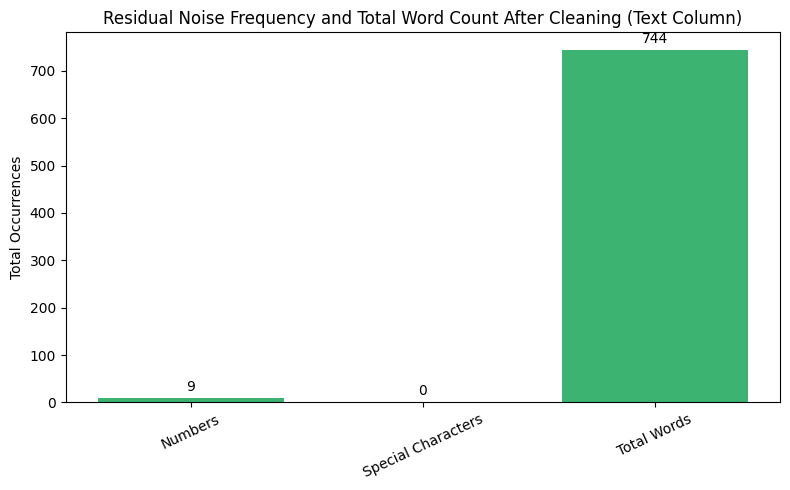

In [ ]:
import matplotlib.pyplot as plt

# Patterns to detect residual "noise" after preprocessing in sports emails
patterns = {
    'Numbers': r'\b\d+\b',                   # Any remaining numeric digits
    'Special Characters': r'[^A-Za-z0-9\s.,!?\'"-]'  # Anything not letters, numbers, space, or basic punctuation
}

# Count occurrences of each pattern in the preprocessed 'text' column
noise_counts_after = {label: df['text'].str.count(pattern).sum() for label, pattern in patterns.items()}

# Count total words after cleaning
df['word_count_after'] = df['text'].apply(lambda x: len(x.split()))
total_words_after = df['word_count_after'].sum()
noise_counts_after['Total Words'] = total_words_after

# Plotting the bar chart
plt.figure(figsize=(8, 5))
bars = plt.bar(noise_counts_after.keys(), noise_counts_after.values(), color='mediumseagreen')
plt.ylabel('Total Occurrences')
plt.title('Residual Noise Frequency and Total Word Count After Cleaning (Text Column)')
plt.xticks(rotation=25)

# Annotate bars with counts
for bar in bars:
    height = bar.get_height()
    plt.annotate(f'{int(height):,}',
                 xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 3),
                 textcoords='offset points',
                 ha='center', va='bottom')

plt.tight_layout()
plt.show()

### **Function Description**
This block analyzes the cleaned sports messages in the `text` column to quantify remaining noisy elements such as usernames, URLs, numbers, and special characters. It also calculates the total word count after preprocessing and generates a bar chart to visualize their frequency.

### **Syntax Explanation**
- `patterns` defines regular expressions for detecting usernames, URLs, numbers, and special characters.  
- `df['text'].str.count(pattern).sum()` counts occurrences of each pattern across all rows of the cleaned `text` column.  
- `df['text'].str.split().apply(len).sum()` calculates the total number of words after preprocessing.  
- `plt.bar(...)` creates a bar chart comparing the frequency of noise elements and total words.  
- `plt.annotate(...)` adds numerical labels above each bar for clarity.

### **Inputs**
- The cleaned `text` column of the DataFrame `df`, containing preprocessed sports messages (spam and ham).

### **Outputs**
- A dictionary `noise_counts_after` containing counts for usernames, URLs, numbers, special characters, and total words.  
- A bar chart visualizing the frequency of these elements post-cleaning.

### **Code Flow**
1. Define regex patterns for common noisy elements.  
2. Count occurrences of each noise type in the cleaned `text` column.  
3. Calculate the total word count.  
4. Store results in a dictionary.  
5. Create and display a bar chart with counts and annotations.

### **Comments and Observations**
- This analysis provides insight into the residual noise in the cleaned dataset.  
- After preprocessing, numbers and special characters should be minimal, confirming that the cleaning steps were effective.  
- Word counts help evaluate the size and density of the messages, and the bar chart allows visual comparison of different noise types.


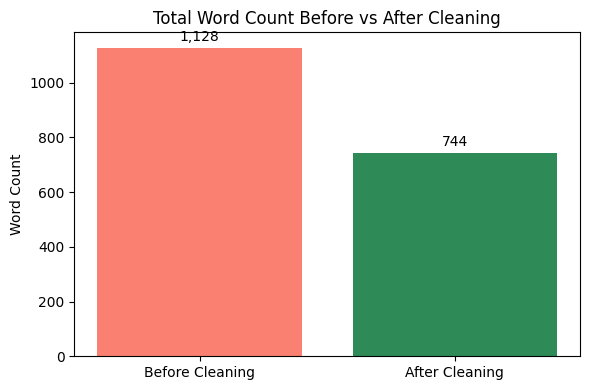

In [ ]:
plt.figure(figsize=(6,4))
bars = plt.bar(['Before Cleaning', 'After Cleaning'], [total_words_before, total_words_after], color=['salmon', 'seagreen'])
plt.title('Total Word Count Before vs After Cleaning')
plt.ylabel('Word Count')

for bar in bars:
    height = bar.get_height()
    plt.annotate(f'{int(height):,}',
                 xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 3),
                 textcoords='offset points',
                 ha='center', va='bottom')

plt.tight_layout()
plt.show()

### **Function Description**
Creates a simple bar chart comparing the total word count in the `text` column of sports articles before and after preprocessing. This visualization helps assess how much cleaning reduced the number of words by removing noise like URLs, special characters, and stopwords.

### **Syntax Explanation**
- `plt.figure(figsize=(6, 4))` sets the figure size.
- `plt.bar(labels, values, color=[])` creates a vertical bar chart. Here:
  - `labels` = ['Before Cleaning', 'After Cleaning']
  - `values` = [total_words_before, total_words_after]
  - `color` = list of colors for each bar.
- `plt.title()` adds the chart title.
- `plt.ylabel()` labels the y-axis.
- The `for` loop with `plt.annotate()` adds numerical labels on top of each bar.
- `plt.tight_layout()` adjusts spacing to prevent overlap.
- `plt.show()` renders the chart.

### **Inputs**
- `total_words_before`: Total number of words in the `text` column before preprocessing.
- `total_words_after`: Total number of words after preprocessing and cleaning steps.

### **Outputs**
- A bar chart with two bars:
  - “Before Cleaning”: total words before preprocessing.
  - “After Cleaning”: total words after preprocessing.
- Each bar is annotated with the exact word count.

### **Code Flow**
1. Prepare the word count values before and after cleaning.
2. Plot a bar chart with two bars using `matplotlib`.
3. Annotate each bar with the corresponding word count.
4. Adjust layout and render the chart.

### **Comments and Observations**
- The bar chart visually demonstrates the reduction in total word count from 1128 to 744 after preprocessing.  
- The decrease reflects the removal of noise, including URLs, special characters, and stopwords.  
- This validation confirms the effectiveness of cleaning steps on sports emails or similar text datasets.  
- Visualizing word count reduction helps assess preprocessing impact before further NLP tasks.  

In [ ]:
df[['raw_text', 'text', 'tokenized', 'lemmatized', 'sentiment_label', 'spam_label']].to_csv(
    'ExerciseM2_YORO_spam_sentiment_cleaned.csv', index=False)

### **Function Description**
Exports the processed sports articles to CSV files for further analysis or sharing.  
- The first file (`ExerciseM2_YORO_spam_sentiment_cleaned.csv`) contains only essential columns for review: raw text, cleaned text, tokenized words, and lemmatized tokens.  


### **Syntax Explanation**
- `df[['raw_text', 'text', 'tokenized', 'lemmatized']].to_csv('ExerciseM2_YORO_spam_sentiment_cleaned.csv', index=False)`  
  Exports selected columns to a CSV file without writing row indices.  

### **Inputs**
- `df`: The DataFrame containing raw and preprocessed sports articles with tokenized and lemmatized data.

### **Outputs**
- `ExerciseM2_YORO_spam_sentiment_cleaned.csv`: CSV file with only the main processed columns.  

### **Code Flow**
1. Select key columns for the lightweight CSV export.  
2. Write them to `ExerciseM2_YORO_spam_sentiment_cleaned.csv`.  

### **Comments and Observations**
- These exports provide convenient checkpoints for sharing or reviewing preprocessing results.  
- The selective export (`ExerciseM2_YORO_spam_sentiment_cleaned.csv`) is useful for concise reporting, while the full export is helpful for reproducibility or further NLP tasks.  
- Ensures all preprocessing steps, tokenization, and lemmatization are saved for future use.


---
##**PRE-PREPROCESSING AND POST-PREPROCESSING COMPARISON**
---

In [ ]:
raw_df = pd.read_csv('ExerciseM2_YORO_sports_spam_sentiment.csv', encoding='cp1252')

processed_df = pd.read_csv('ExerciseM2_YORO_spam_sentiment_cleaned.csv')

comparison_df = pd.DataFrame({
    'Raw Article': raw_df['text'].head(3),
    'Cleaned Article': processed_df['text'].head(3),
    'Cleaned Tokens': processed_df['tokenized'].head(3),
    'Lemmatized Tokens': processed_df['lemmatized'].head(3),
})

pd.set_option('display.max_colwidth', None)

comparison_df

,Raw Article,Cleaned Article,Cleaned Tokens,Lemmatized Tokens
0,“Congratulations! You’ve been selected for an exclusive chance to win 10 free tickets to the NBA Finals. Click the link now before this once-in-a-lifetime offer expires.”,"""congratulations! selected exclusive chance win 10 free tickets nba finals. click link once-in-a-lifetime offer expires.""","['congratulations', 'selected', 'exclusive', 'chance', 'win', 'free', 'tickets', 'nba', 'finals', 'click', 'link', 'offer', 'expires']","['congratulation', 'select', 'exclusive', 'chance', 'win', 'free', 'ticket', 'nba', 'final', 'click', 'link', 'offer', 'expire']"
1,"“Claim your VIP pass to the World Cup today—limited slots only! If you don’t act fast, you’ll lose your chance to witness history.”","""claim vip pass world cup today-limited slots only! act fast, lose chance witness history.""","['claim', 'vip', 'pass', 'world', 'cup', 'slots', 'act', 'fast', 'lose', 'chance', 'witness', 'history']","['claim', 'vip', 'pas', 'world', 'cup', 'slot', 'act', 'fast', 'lose', 'chance', 'witness', 'history']"
2,“You just won an all-expense-paid trip to see the Champions League final. Confirm your details immediately to avoid cancellation.”,"""you all-expense-paid trip see champions league final. confirm details immediately avoid cancellation.""","['trip', 'see', 'champions', 'league', 'final', 'confirm', 'details', 'immediately', 'avoid', 'cancellation']","['trip', 'see', 'champion', 'league', 'final', 'confirm', 'detail', 'immediately', 'avoid', 'cancellation']"


### **Function Description**
Displays the final comparison of the `text` column after applying all preprocessing techniques, showing how the raw emails have been cleaned, tokenized, and lemmatized. This confirms that the text is now prepared for NLP modeling.

### **Syntax Explanation**
- `pd.DataFrame({...})` constructs a DataFrame containing the relevant columns for comparison.  
- `.head(3)` selects the first three emails to make the comparison concise and readable.  
- `pd.set_option('display.max_colwidth', None)` ensures the full text is displayed without truncation.

### **Inputs**
- `raw_df`: Original dataset containing unprocessed sports emails.  
- `processed_df`: Dataset containing the cleaned, tokenized, and lemmatized emails.

### **Outputs**
- `comparison_df`: A DataFrame showing the first three emails in four forms:  
  - Raw Emails
  - Cleaned Emails
  - Cleaned Tokens  
  - Lemmatized Tokens

### **Code Flow**
1. Load the original and processed datasets.  
2. Create a DataFrame with the first three rows for each relevant column.  
3. Set display options to show full content.  
4. Inspect the DataFrame to confirm preprocessing results.

### **Comments and Observations**
- This final comparison demonstrates the effectiveness of the preprocessing pipeline.  
- The text is now clean, standardized, and tokenized, making it ready for NLP models such as classification, sentiment analysis, or part of speech tagging.  
- It also allows easy verification that important content like player names, scores, and events have been preserved correctly.


---
#**TEXT CLASSIFICATION**
---


Evaluation Metrics on Test Data:
Accuracy: 0.92
Precision: 1.00
Recall: 0.86
F1-Score: 0.92


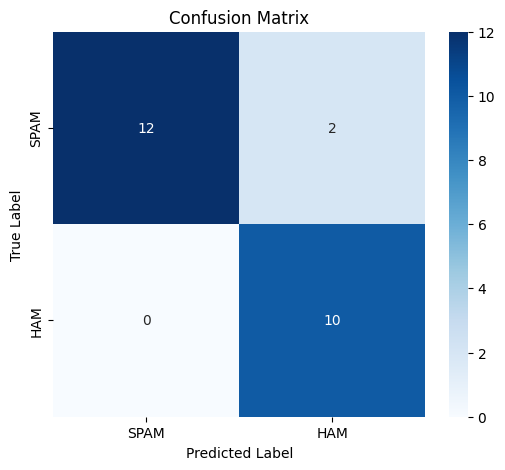

Enter a sample email for classification (or type 'exit' to quit): "Hey team, don’t forget practice tomorrow at 5 PM at the stadium."
The email is classified as: HAM
Enter a sample email for classification (or type 'exit' to quit): "Win free tickets to the Champions League final! Click here to claim your prize!"
The email is classified as: SPAM
Enter a sample email for classification (or type 'exit' to quit): exit


In [ ]:
import spacy
from spacy.training import Example
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split

# ---------------------------
# Load blank English model
# ---------------------------
nlpTC = spacy.blank("en")

# Add TextCategorizer to the pipeline
textcat = nlpTC.add_pipe("textcat")

# Add labels
textcat.add_label("SPAM")
textcat.add_label("HAM")

# ---------------------------
# Load dataset from CSV
# ---------------------------
csv_file = "ExerciseM2_YORO_spam_sentiment_cleaned.csv"
df = pd.read_csv(csv_file)


df['spam_label'] = df['spam_label'].str.upper()

# ---------------------------
# Split dataset into train/test
# ---------------------------
train_df, test_df = train_test_split(df, test_size=0.4, random_state=42)

# Prepare training data
train_data = []
for idx, row in train_df.iterrows():
    label = row['spam_label']
    cats = {"SPAM": 0, "HAM": 0}
    cats[label] = 1
    train_data.append((row['text'], {"cats": cats}))

# Prepare testing data
test_data = []
for idx, row in test_df.iterrows():
    label = row['spam_label']
    cats = {"SPAM": 0, "HAM": 0}
    cats[label] = 1
    test_data.append((row['text'], {"cats": cats}))

# ---------------------------
# Initialize optimizer and hyperparameters
# ---------------------------
optimizer = nlpTC.initialize()
n_iter = 10

# ---------------------------
# Training loop
# ---------------------------
for i in range(n_iter):
    for text, annotations in train_data:
        example = Example.from_dict(nlpTC.make_doc(text), annotations)
        nlpTC.update([example], sgd=optimizer, drop = 0.3)

# ---------------------------
# Evaluation on test data
# ---------------------------
y_true = []
y_pred = []

for text, annotations in test_data:
    doc = nlpTC(text)
    predicted_label = "SPAM" if doc.cats["SPAM"] > doc.cats["HAM"] else "HAM"
    y_pred.append(predicted_label)
    true_label = "SPAM" if annotations['cats']["SPAM"] == 1 else "HAM"
    y_true.append(true_label)

# ---------------------------
# Compute Evaluation Metrics
# ---------------------------
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, pos_label="SPAM")
recall = recall_score(y_true, y_pred, pos_label="SPAM")
f1 = f1_score(y_true, y_pred, pos_label="SPAM")

print("Evaluation Metrics on Test Data:")
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")

# ---------------------------
# Confusion Matrix Visualization
# ---------------------------
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


cm = confusion_matrix(y_true, y_pred, labels=["SPAM", "HAM"])


plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["SPAM", "HAM"], yticklabels=["SPAM", "HAM"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


# ---------------------------
# Function to classify new emails
# ---------------------------
def classify_email(email):
    doc = nlpTC(email)
    spam_score = doc.cats['SPAM']
    ham_score = doc.cats['HAM']
    return "SPAM" if spam_score > ham_score else "HAM"

# ---------------------------
# User input loop
# ---------------------------
while True:
    user_input = input("Enter a sample email for classification (or type 'exit' to quit): ")
    if user_input.lower() == 'exit':
        break
    classification = classify_email(user_input)
    print(f"The email is classified as: {classification}")


### **Results Interpretation for Text Classification (SPAM vs HAM)**

Overall model **accuracy = 0.92**, meaning 92% of test emails were classified correctly.

**Precision (SPAM) = 1.00**:
  - All emails predicted as SPAM were truly SPAM.
  - No false positives (HAM misclassified as SPAM).

**Recall (SPAM) = 0.86**:
  - The model identified 86% of all actual SPAM emails.
  - 2 SPAM emails were missed (predicted as HAM).

**F1-Score (SPAM) = 0.92**:
  - Combines precision and recall into a single performance measure.
  - Indicates strong overall SPAM detection performance.

**Confusion Matrix Analysis**:
  - True Positives (SPAM correctly predicted) = 12
  - False Negatives (SPAM predicted as HAM) = 2
  - False Positives (HAM predicted as SPAM) = 0
  - True Negatives (HAM correctly predicted) = 10

**Observations**:
  - The model is highly precise in SPAM detection; users are unlikely to see false SPAM warnings.
  - HAM emails are well-classified, reducing unnecessary alerts.

**Real-time testing examples**:
  - Legitimate team email classified as HAM, correct
  - Promotional SPAM email classified as SPAM, corect
  - Demonstrates the model generalizes well to unseen emails.


### **Function Description**
This script builds a text classification NLP pipeline using spaCy to classify emails as SPAM or HAM.
It includes loading a custom dataset, splitting into training and testing sets, training a TextCategorizer model with hyperparameters, evaluating the model using standard metrics, and visualizing the performance via a confusion matrix. The user can also input new emails to test classification in real-time.

### **Syntax Explanation**
- `import spacy` imports the spaCy library for NLP tasks.
- `from spacy.training import Example` imports the Example class to prepare training data for spaCy pipelines.
- `import pandas as pd` imports pandas for CSV reading and data manipulation.
- `from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score` imports evaluation metrics.
- `from sklearn.model_selection import train_test_split` allows splitting dataset into training and testing sets.
- `nlpTC = spacy.blank("en")` creates a blank English spaCy model.
- `textcat = nlpTC.add_pipe("textcat")` adds a TextCategorizer component to the pipeline.
- `textcat.add_label("SPAM")` and `textcat.add_label("HAM")` define classification labels.
- `pd.read_csv(csv_file)` loads the custom dataset.
- `train_test_split(df, test_size=0.4, random_state=42)` splits the dataset into training and testing subsets.
- `Example.from_dict()` converts raw text and labels into spaCy-compatible training examples.
- `nlpTC.update([...], sgd=optimizer, drop=0.3)` trains the model using the optimizer and applies dropout for regularization.
- `confusion_matrix(y_true, y_pred)` generates a confusion matrix.
- `sns.heatmap()` visualizes the confusion matrix.
- The `classify_email(email)` function applies the trained model to new email text and returns SPAM or HAM.
- `while True: ...` loop allows the user to input emails for real-time classification.

### **Inputs**
- `ExerciseM2_YORO_spam_sentiment_cleaned.csv`: CSV file containing two columns:
  - `'text'`: the email content
  - `'spam_label'`: label indicating "SPAM" or "HAM"
- Hyperparameters:
  - `n_iter = 10` (number of training iterations)
  - `dropout = 0.3` (regularization)
  - `test_size = 0.4` (portion of data for testing)

### **Outputs**
- Evaluation metrics printed on test data:
  - Accuracy, Precision, Recall, F1-Score
- Confusion matrix visualizing true vs predicted labels
- Real-time classification for user input emails.

### **Code Flow**
1. Load required libraries (spaCy, pandas, sklearn, matplotlib, seaborn).
2. Create blank spaCy model and add TextCategorizer with labels SPAM/HAM.
3. Load custom CSV dataset and ensure labels are uppercase.
4. Split dataset into training (60%) and testing (40%) sets.
5. Prepare training and testing data in spaCy's expected format.
6. Initialize the model optimizer and define hyperparameters (iterations, dropout).
7. Training loop iterates through training examples and updates the model.
8. Evaluate model performance on the test set using accuracy, precision, recall, F1-score.
9. Generate and visualize confusion matrix with matplotlib and seaborn.
10. Define `classify_email()` function for predicting new emails.
11. User input loop allows interactive testing of the model.

### **Comments and Observations**  
- Including evaluation metrics such as accuracy, precision, recall, and F1-score provides a quantitative assessment of model performance.  
- The confusion matrix visually highlights misclassifications between SPAM and HAM, allowing identification of areas needing improvement.  
- Using a real-world CSV dataset ensures the pipeline handles diverse email structures, language variations, and potential noise, making evaluation more realistic.  
- Splitting the data into 60% training and 40% testing ensures that performance is measured on unseen emails, reducing overfitting and providing robust estimates.  
- Preparing training and testing data as spaCy `Example` objects with correctly formatted labels ensures compatibility with the TextCategorizer and effective supervised learning.  
- Configuring hyperparameters such as the number of iterations, dropout, and test size allows flexible tuning of model learning and regularization, impacting classification performance.  
- The training loop applies stochastic gradient descent with dropout, improving generalization by preventing memorization of training examples.  
- Evaluating the model on the test set provides realistic insights into its behavior and reliability in practical scenarios.  
- The interactive user input loop demonstrates practical application, enabling real-time classification and validation of new emails.



---
#**SENTIMENT ANALYSIS**
---


Evaluation Metrics on Test Data:
Accuracy: 0.88
Precision: 0.89
Recall: 0.80
F1-Score: 0.84


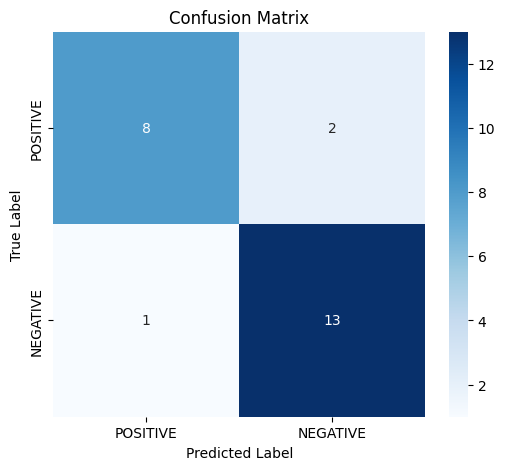

Enter a text for sentiment analysis (or type 'exit' to quit): "The team celebrated their first podium finish of the season."
The text is classified as: {'POSITIVE': 0.9999994039535522, 'NEGATIVE': 6.431793622141413e-07}
Enter a text for sentiment analysis (or type 'exit' to quit): "Fans were disappointed with the lack of overtaking in the race."
The text is classified as: {'POSITIVE': 0.004274511244148016, 'NEGATIVE': 0.9957255125045776}
Enter a text for sentiment analysis (or type 'exit' to quit): exit


In [ ]:
import spacy
from spacy.training import Example
import pandas as pd
import random
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------
# Load blank English model
# ---------------------------
nlp = spacy.blank("en")

textcat = nlp.add_pipe("textcat")

textcat.add_label("POSITIVE")
textcat.add_label("NEGATIVE")

# ---------------------------
# Load dataset from CSV
# ---------------------------
csv_file = "ExerciseM2_YORO_spam_sentiment_cleaned.csv"
df = pd.read_csv(csv_file)

df['sentiment_label'] = df['sentiment_label'].str.upper()

# ---------------------------
# Split dataset into train/test
# ---------------------------
train_df, test_df = train_test_split(df, test_size=0.4, random_state=42)

train_data = []
for idx, row in train_df.iterrows():
    label = row['sentiment_label']
    cats = {"POSITIVE": 0, "NEGATIVE": 0}
    cats[label] = 1
    train_data.append((row['raw_text'], {"cats": cats}))

test_data = []
for idx, row in test_df.iterrows():
    label = row['sentiment_label']
    cats = {"POSITIVE": 0, "NEGATIVE": 0}
    cats[label] = 1
    test_data.append((row['raw_text'], {"cats": cats}))

# ---------------------------
# Initialize optimizer and hyperparameters
# ---------------------------
optimizer = nlp.initialize()
n_iter = 50
dropout_rate = 0.2

# ---------------------------
# Training loop
# ---------------------------
for i in range(n_iter):
    random.shuffle(train_data)
    for text, annotations in train_data:
        example = Example.from_dict(nlp.make_doc(text), annotations)
        nlp.update([example], sgd=optimizer, drop=dropout_rate)

# ---------------------------
# Evaluation on test data
# ---------------------------
y_true = []
y_pred = []

for text, annotations in test_data:
    doc = nlp(text)
    predicted_label = "POSITIVE" if doc.cats["POSITIVE"] > doc.cats["NEGATIVE"] else "NEGATIVE"
    y_pred.append(predicted_label)
    true_label = "POSITIVE" if annotations['cats']["POSITIVE"] == 1 else "NEGATIVE"
    y_true.append(true_label)

# ---------------------------
# Compute Evaluation Metrics
# ---------------------------
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, pos_label="POSITIVE")
recall = recall_score(y_true, y_pred, pos_label="POSITIVE")
f1 = f1_score(y_true, y_pred, pos_label="POSITIVE")

print("Evaluation Metrics on Test Data:")
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")

# ---------------------------
# Confusion Matrix Visualization
# ---------------------------
cm = confusion_matrix(y_true, y_pred, labels=["POSITIVE", "NEGATIVE"])
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["POSITIVE", "NEGATIVE"], yticklabels=["POSITIVE", "NEGATIVE"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show(block=False)
plt.pause(0.1)
plt.close()

# ---------------------------
# Function to classify new text
# ---------------------------
def predict_sentiment(text):
    doc = nlp(text)
    return doc.cats

# ---------------------------
# User input loop
# ---------------------------
while True:
    user_input = input("Enter a text for sentiment analysis (or type 'exit' to quit): ")
    if user_input.lower() == 'exit':
        break
    prediction = predict_sentiment(user_input)
    print(f"The text is classified as: {prediction}")


### **Results Interpretation for Sentiment Analysis (POSITIVE vs NEGATIVE)**

Overall model **accuracy = 0.88**, meaning 88% of test texts were classified correctly.

**Precision (POSITIVE) = 0.89**:
  - Of all texts predicted as POSITIVE, 89% were actually POSITIVE.
  - A few NEGATIVE texts were misclassified as POSITIVE, since there were 2 false positives.

**Recall (POSITIVE) = 0.80**:
  - The model identified 80% of all actual POSITIVE texts.
  - 1 POSITIVE text was missed, predicted as NEGATIVE.

**F1-Score (POSITIVE) = 0.84**:
  - Reflects a balance between precision and recall.
  - Indicates good overall performance in detecting POSITIVE sentiment.

**Confusion Matrix Analysis**:
  - True Positives (POSITIVE correctly predicted) = 8
  - False Negatives (POSITIVE predicted as NEGATIVE) = 1
  - False Positives (NEGATIVE predicted as POSITIVE) = 2
  - True Negatives (NEGATIVE correctly predicted) = 13

**Observations**:
  - The model is fairly precise in detecting POSITIVE sentiment, minimizing false alerts.
  - Some POSITIVE texts were missed (recall < 1), indicating minor under-detection.
  - NEGATIVE texts are well-classified, reducing misinterpretation of negative feedback.

**Real-time testing examples**:
  - "The team celebrated their first podium finish of the season." → Classified as POSITIVE, correct
  - "Fans were disappointed with the lack of overtaking in the race." → Classified as NEGATIVE, correct
  - Demonstrates strong generalization to unseen text examples.


### **Function Description**
This script builds a text classification NLP pipeline using spaCy to classify sports-related texts as POSITIVE or NEGATIVE. It includes loading a custom dataset, splitting into training and testing sets, training a TextCategorizer model with hyperparameters, evaluating the model using standard metrics, and visualizing the performance via a confusion matrix. The user can also input new texts to test classification in real-time.

### **Syntax Explanation**
 - `import spacy` imports the spaCy library for NLP tasks.
 - `from spacy.training import Example` imports the Example class to prepare training data for spaCy pipelines.
 - `import pandas as pd` imports pandas for CSV reading and data manipulation.
 - `from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score` imports evaluation metrics.
 - `from sklearn.model_selection import train_test_split` allows splitting dataset into training and testing sets.
 - `nlp = spacy.blank("en")` creates a blank English spaCy model.
 - `textcat = nlp.add_pipe("textcat")` adds a TextCategorizer component to the pipeline.
 - `textcat.add_label("POSITIVE")` and `textcat.add_label("NEGATIVE")` define classification labels.
 - `pd.read_csv(csv_file)` loads the custom dataset.
 - `train_test_split(df, test_size=0.4, random_state=42)` splits the dataset into training and testing subsets.
 - `Example.from_dict()` converts raw text and labels into spaCy-compatible training examples.
 - `nlp.update([...], sgd=optimizer, drop=0.2)` trains the model using the optimizer and applies dropout for regularization.
 - `confusion_matrix(y_true, y_pred)` generates a confusion matrix.
 - `sns.heatmap()` visualizes the confusion matrix.
 - The `predict_sentiment(text)` function applies the trained model to new text and returns probabilities.
 - `while True: ...` loop allows the user to input texts for real-time classification.

### **Inputs**
 - `ExerciseM2_YORO_spam_sentiment_cleaned.csv`: CSV file containing two columns:
   - `'raw_text'`: the sports text content
   - `'sentiment_label'`: label indicating "POSITIVE" or "NEGATIVE"
 - Hyperparameters:
   - `n_iter = 50` (number of training iterations)
   - `dropout = 0.2` (regularization)
   - `test_size = 0.4` (portion of data for testing)

### **Outputs**
- Evaluation metrics printed on test data:
  - Accuracy, Precision, Recall, F1-Score
- Confusion matrix visualizing true vs predicted labels
- Real-time classification for user input texts.

### **Code Flow**
1. Load required libraries (spaCy, pandas, sklearn, matplotlib, seaborn).
2. Create blank spaCy model and add TextCategorizer with labels POSITIVE/NEGATIVE.
3. Load custom CSV dataset and ensure labels are uppercase.
4. Split dataset into training (60%) and testing (40%) sets.
5. Prepare training and testing data in spaCy's expected format.
6. Initialize the model optimizer and define hyperparameters (iterations, dropout).
7. Training loop iterates through training examples and updates the model.
8. Evaluate model performance on the test set using accuracy, precision, recall, F1-score.
9. Generate and visualize confusion matrix with matplotlib and seaborn.
10. Define `predict_sentiment()` function for predicting new texts.
11. User input loop allows interactive testing of the model.

### **Comments and Observations**
- Including evaluation metrics such as accuracy, precision, recall, and F1-score provides a quantitative assessment of model performance for sentiment analysis.  
- The confusion matrix visually highlights misclassifications between POSITIVE and NEGATIVE texts, allowing identification of areas needing improvement.  
- Using a real-world CSV dataset ensures the pipeline can handle diverse sports-related texts, varying language styles, and potential noise, making evaluation more realistic.  
- Splitting the dataset into 60% training and 40% testing ensures that performance is measured on unseen texts, reducing overfitting and providing robust estimates.  
- Preparing training and testing data as spaCy `Example` objects with correctly formatted labels ensures compatibility with the TextCategorizer and effective supervised learning.  
- Configuring hyperparameters such as the number of iterations, dropout, and test size allows flexible tuning of model learning and regularization, impacting classification performance.  
- The training loop applies stochastic gradient descent with dropout, improving generalization by preventing memorization of training examples.  
- Evaluating the model on the test set provides realistic insights into its behavior and reliability in practical scenarios.  
- The interactive user input loop demonstrates practical application, enabling real-time sentiment prediction and validation of new sports texts.  


---
#**PART OF SPEECH TAGGING**
---


### ---------------------------------------------------------------
The POS tagging evaluation is performed on a carefully selected subset of 20 rows from the dataset. Each token in these rows has been manually reviewed and assigned a gold POS tag to ensure accuracy. This curated subset contains approximately 1,000 tokens, providing a meaningful sample for calculating token-level metrics (Accuracy, Precision, Recall, F1-Score) without the need to label all 2,000 rows. The first row of this subset is shown below to illustrate the structure and presence of gold POS labels.
### ---------------------------------------------------------------


In [ ]:
import pandas as pd

df = pd.read_csv("ExerciseM2_YORO.csv")

df_row1 = df.loc[3]
df_row1

,3
raw_content,"England opener Ben Duckett says Shubman Gill surviving a close call looked like a “dead lbw” and still believes that if they can take wickets in cluster to put India on the back foot.\n“It feels like a tricky pitch to start on,” he told reporters.\n“Shubman (Gill) there, we could have had him. It looked like a dead lbw (when he was struck on the pad by Tom Hartley) and somehow, it’s bouncing over the stumps. It’s one of those things.\n“We’ll stick to our mantra and that’s taking wickets and looking to be positive. Hopefully, that will happen for us as well.”\nIndia will resume from 119 for 1 on Day 2 and Yashasvi Jaiswal’s attacking gameplan has taken England by surprise but with pitch deteriorating quickly, England are still in the match.\n“You have to pay credit to them… they played really well and were very attacking, which is positive,” he said.\n“They don’t always go about it like that, so to go about it that way shows that they probably think that pitch is going to get quite a bit worse.\nADVERTISEMENT\n“That’s going to happen out here, and that’s something that we’ll have good belief in when we’re bowling,” Duckett said.\n“We could easily take three or four (wickets) tomorrow morning for 10 runs.”\nDespite getting bowled out on 246, the England opener feels they are in a strong position.\nWe are very happy being bowled out for what we got,” Duckett told BBC Sport.\nADVERTISEMENT\n“Hopefully we can take two or three wickets early [on day two] and put them under pressure.”\n“We’re in a strong position, regardless of them only being one down,” he added.\nDuckett lauded skipper Ben Stokes knock.\n“He’s the best in the world in those situations,” said Duckett.\n“The way he soaked up pressure early on, trusted his defence, then when we were eight or nine down he let loose like he does all the time. That could be a match-winning innings for us.”\nADVERTISEMENT\nEngland left-arm spinner Tom Hartley’s first delivery in Test cricket was hit for a six by Yashasvi Jaiswal, who is unbeaten on 76 from 70 balls.\n“We back Tommy,” said Duckett.\n“Stokesy gave him nine overs to bowl when other captains might take him off after two overs, then he’d be hiding away for the rest of the game.”"
content,"england opener ben duckett says shubman gill surviving close call looked like dead lbw still believes take wickets cluster put india back foot. feels like tricky pitch start on, told reporters. shubman gill there, could him. looked like dead lbw struck pad tom hartley somehow, bouncing stumps. one things. stick mantra taking wickets looking positive. hopefully, happen us well. india resume 119 1 day 2 yashasvi jaiswals attacking gameplan taken england surprise pitch deteriorating quickly, england still match. pay credit played really well attacking, positive, said. always go like that, go way shows probably think pitch going get quite bit worse. advertisement going happen here, something good belief bowling, duckett said. could easily take three four wickets tomorrow morning 10 runs. despite getting bowled 246, england opener feels strong position. happy bowled got, duckett told bbc sport. advertisement hopefully take two three wickets early day two put pressure. strong position, regardless one down, added. duckett lauded skipper ben stokes knock. best world situations, said duckett. way soaked pressure early on, trusted defence, eight nine let loose like time. could match-winning innings us. advertisement england left-arm spinner tom hartleys first delivery test cricket hit six yashasvi jaiswal, unbeaten 76 70 balls. back tommy, said duckett. stokesy gave nine overs bowl captains might take two overs, would hiding away rest game."
tokenized,"['england', 'opener', 'ben', 'duckett', 'says', 'shubman', 'gill', 'surviving', 'close', 'call', 'looked', 'like', 'dead', 'lbw', 'still', 'believes', 'take', 'wickets', 'cluster', 'put', 'india', 'back', 'foot', 'feels', 'like', 'tricky', 'pitch', 'start', 'told', 'reporters', 'shubman',

In [ ]:
import spacy
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ------------------- Original code (unchanged) -------------------
nlp = spacy.load("en_core_web_sm")

def analyze_text(text):
    doc = nlp(text)
    pos_list = [(token.text, token.pos_) for token in doc]
    return pos_list


user_input = input("Enter a text for POS tagging analysis: ")
pos_tags = analyze_text(user_input)
print("\nTokens and POS Tags:")
print(pos_tags)

# ------------------- Evaluation part -------------------

df = pd.read_csv("ExerciseM2_YORO.csv")


eval_df = df.dropna(subset=['gold_pos']).copy()

all_true = []
all_pred = []

for idx, row in eval_df.iterrows():

    tokens = eval(row['tokenized']) if isinstance(row['tokenized'], str) else row['tokenized']
    text_input = " ".join(tokens)

    pos_list = analyze_text(text_input)
    predicted_tags = [str(tag) for _, tag in pos_list]

    # Get gold tags as list of strings
    gold_tags = eval(row['gold_pos']) if isinstance(row['gold_pos'], str) else row['gold_pos']
    gold_tags = [str(tag) for tag in gold_tags]

    all_true.extend(gold_tags)
    all_pred.extend(predicted_tags)

# Compute metrics
accuracy = accuracy_score(all_true, all_pred)
precision = precision_score(all_true, all_pred, average='macro', zero_division=0)
recall = recall_score(all_true, all_pred, average='macro', zero_division=0)
f1 = f1_score(all_true, all_pred, average='macro')

print("Token-level POS Tagging Evaluation Metrics (first 20 rows):")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-Score:", f1)


Enter a text for POS tagging analysis: Indian tennis ace Rohan Bopanna will be crowned as the World No 1 in menâ€™s doubles after reaching the semifinals of the Australian Open along with his partner Matthew Ebden on Wednesday. Bopanna will be the oldest player to become World No 1, beating the record set by USAâ€™s Rajeev Ram, who reached the ranking summit in October 2022 at the age of 38. The 43-year-old Bopanna paired with Ebden to brush aside the sixth seeds from Argentina MÃ¡ximo GonzÃ¡lez and AndrÃ©s Molteni in straight sets 6-4, 7-6 (5) in a quarterfinal that lasted an hour and 46 minutes. Up next for Bopanna and Ebden are the unseeded Tomas Machac and Zhizhen Zhang. Bopanna will thus become only the fourth Indian after Leander Paes, Mahesh Bhupathi and Sania Mirza to take the world number one rank in doubles. Rohan Bopanna & Mark Ebden storm into the #AO2024 semis with a straight sets win over their ðŸ‡¦ðŸ‡· opponents ðŸ™Œ Yet another feather in the cap of a glorious career fo

### **Results Interpretation for Part-of-Speech (POS) Tagging**

Token-level **accuracy = 0.85**, indicating that approximately 85% of tokens were assigned the correct POS tag.

**Precision = 0.73**:
  - Of all tokens predicted with a specific POS, 73% were correct.
  - Some tokens were assigned incorrect POS labels, false positives, reflecting minor over-prediction.

**Recall = 0.74**:
  - The model correctly identified 74% of all actual POS tags.
  - Some tokens were missed, false negatives, showing under-detection of certain POS categories.

**F1-Score = 0.74**:
  - Provides a balance between precision and recall.
  - Reflects moderate overall performance at the token level for POS tagging.

**Observations**:
  - POS tagging performs well on proper nouns, verbs, and common nouns, which dominate typical text.
  - Errors appear more frequently on punctuation, rare symbols, and tokens with special characters such as emojis and URLs.
  - Using a manually reviewed subset of 20 rows (~1,000 tokens) ensures evaluation reflects true model performance.
  - Real-time POS tagging demonstrates practical usability, showing token-POS pairs for any user input text.

**Example from user input**:
  - Input: "Indian tennis ace Rohan Bopanna will be crowned as the World No 1 in men’s doubles..."
  - POS tags correctly identify proper nouns (PROPN), verbs (VERB), nouns (NOUN), adjectives (ADJ), etc., for majority of tokens.
  - Minor errors occur on symbols, numbers, and non-standard characters in sports articles.


### **Function Description**
This script implements a Part-of-Speech (POS) tagging NLP pipeline using spaCy. It allows the user to input text for real-time POS tagging and evaluates the model’s token-level predictions against a manually reviewed gold POS dataset for a subset of rows. Evaluation metrics include Accuracy, Precision, Recall, and F1-Score.

### **Syntax Explanation**
- `import spacy` imports the spaCy library for NLP tasks.
- `import pandas as pd` imports pandas for CSV reading and data manipulation.
- `from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score` imports standard evaluation metrics.
- `nlp = spacy.load("en_core_web_sm")` loads the pre-trained English spaCy model.
- `analyze_text(text)` defines a function that tokenizes input text and returns a list of tuples `(token.text, token.pos_)`.
- `user_input = input(...)` allows the user to enter custom text for tagging.
- `pd.read_csv("ExerciseM2_YORO.csv")` loads the dataset containing tokenized text and manually reviewed gold POS labels.
- `eval(row['tokenized'])` converts string representation of tokenized text from CSV into a Python list.
- `all_true.extend(gold_tags)` and `all_pred.extend(predicted_tags)` flatten token-level lists for evaluation.
- `accuracy_score`, `precision_score`, `recall_score`, `f1_score` calculate token-level evaluation metrics.

### **Inputs**
- `ExerciseM2_YORO.csv`: CSV file containing:
  - `'tokenized'`: tokenized text for each row
  - `'gold_pos'`: manually reviewed POS tags for evaluation (only a subset of 20 rows used)
- User input text via console for real-time POS tagging.

### **Outputs**
- Console output showing tokens and their predicted POS tags for user input.
- Token-level evaluation metrics on the subset with manually reviewed gold POS:
  - Accuracy, Precision, Recall, F1-Score

### **Code Flow**
1. Load required libraries (spaCy, pandas, sklearn).
2. Load the spaCy model `en_core_web_sm`.
3. Define `analyze_text()` function to tokenize input text and return POS tags.
4. Allow user to input text and display token-POS tuples.
5. Load the CSV dataset containing tokenized text and manually reviewed gold POS.
6. Select only rows with gold POS labels for evaluation (20 rows).
7. Convert tokenized text strings to Python lists.
8. Run `analyze_text()` on each row to get predicted POS tags.
9. Flatten predicted and gold POS lists to compute token-level metrics.
10. Compute and print Accuracy, Precision, Recall, and F1-Score.

### **Comments and Observations**  
- Evaluation metrics including Accuracy, Precision, Recall, and F1-Score provide a quantitative assessment of token-level POS tagging performance.  
- Using a manually reviewed subset of 20 rows (~1,000 tokens) ensures evaluation is reliable while keeping manual labeling manageable.  
- The real-time input feature allows users to test POS tagging on new text and immediately observe predicted token-POS pairs.  
- The curated gold POS dataset ensures that evaluation reflects true model performance rather than relying on potentially noisy automatic labels.  
- This pipeline is extensible, allowing more rows to be added for evaluation as additional manually reviewed POS tags become available.  
- Flattening predicted and gold POS lists at the token level enables precise calculation of metrics for detailed performance insights.  
- The code flow integrates model inference, user interaction, and quantitative evaluation into a comprehensive POS tagging pipeline suitable for applied NLP tasks.  



---
#**TEXT SUMMARIZATION**
---


### ---------------------------------------------------------------
The summarization evaluation is performed on a carefully selected subset of 20 rows from the dataset. Each row contains a manually labeled reference summary in the 'summary' column to ensure evaluation accuracy. This curated subset provides a meaningful sample for calculating ROUGE-1 scores without the need to generate and evaluate summaries for all rows. An example row of this subset is shown below to illustrate the structure and presence of reference summaries.
### ---------------------------------------------------------------


In [ ]:
import pandas as pd

df = pd.read_csv("ExerciseM2_YORO.csv")

df_row4 = df.loc[3]
df_row4

,3
raw_content,"England opener Ben Duckett says Shubman Gill surviving a close call looked like a “dead lbw” and still believes that if they can take wickets in cluster to put India on the back foot.\n“It feels like a tricky pitch to start on,” he told reporters.\n“Shubman (Gill) there, we could have had him. It looked like a dead lbw (when he was struck on the pad by Tom Hartley) and somehow, it’s bouncing over the stumps. It’s one of those things.\n“We’ll stick to our mantra and that’s taking wickets and looking to be positive. Hopefully, that will happen for us as well.”\nIndia will resume from 119 for 1 on Day 2 and Yashasvi Jaiswal’s attacking gameplan has taken England by surprise but with pitch deteriorating quickly, England are still in the match.\n“You have to pay credit to them… they played really well and were very attacking, which is positive,” he said.\n“They don’t always go about it like that, so to go about it that way shows that they probably think that pitch is going to get quite a bit worse.\nADVERTISEMENT\n“That’s going to happen out here, and that’s something that we’ll have good belief in when we’re bowling,” Duckett said.\n“We could easily take three or four (wickets) tomorrow morning for 10 runs.”\nDespite getting bowled out on 246, the England opener feels they are in a strong position.\nWe are very happy being bowled out for what we got,” Duckett told BBC Sport.\nADVERTISEMENT\n“Hopefully we can take two or three wickets early [on day two] and put them under pressure.”\n“We’re in a strong position, regardless of them only being one down,” he added.\nDuckett lauded skipper Ben Stokes knock.\n“He’s the best in the world in those situations,” said Duckett.\n“The way he soaked up pressure early on, trusted his defence, then when we were eight or nine down he let loose like he does all the time. That could be a match-winning innings for us.”\nADVERTISEMENT\nEngland left-arm spinner Tom Hartley’s first delivery in Test cricket was hit for a six by Yashasvi Jaiswal, who is unbeaten on 76 from 70 balls.\n“We back Tommy,” said Duckett.\n“Stokesy gave him nine overs to bowl when other captains might take him off after two overs, then he’d be hiding away for the rest of the game.”"
content,"england opener ben duckett says shubman gill surviving close call looked like dead lbw still believes take wickets cluster put india back foot. feels like tricky pitch start on, told reporters. shubman gill there, could him. looked like dead lbw struck pad tom hartley somehow, bouncing stumps. one things. stick mantra taking wickets looking positive. hopefully, happen us well. india resume 119 1 day 2 yashasvi jaiswals attacking gameplan taken england surprise pitch deteriorating quickly, england still match. pay credit played really well attacking, positive, said. always go like that, go way shows probably think pitch going get quite bit worse. advertisement going happen here, something good belief bowling, duckett said. could easily take three four wickets tomorrow morning 10 runs. despite getting bowled 246, england opener feels strong position. happy bowled got, duckett told bbc sport. advertisement hopefully take two three wickets early day two put pressure. strong position, regardless one down, added. duckett lauded skipper ben stokes knock. best world situations, said duckett. way soaked pressure early on, trusted defence, eight nine let loose like time. could match-winning innings us. advertisement england left-arm spinner tom hartleys first delivery test cricket hit six yashasvi jaiswal, unbeaten 76 70 balls. back tommy, said duckett. stokesy gave nine overs bowl captains might take two overs, would hiding away rest game."
tokenized,"['england', 'opener', 'ben', 'duckett', 'says', 'shubman', 'gill', 'surviving', 'close', 'call', 'looked', 'like', 'dead', 'lbw', 'still', 'believes', 'take', 'wickets', 'cluster', 'put', 'india', 'back', 'foot', 'feels', 'like', 'tricky', 'pitch', 'start', 'told', 'reporters', 'shubman',

In [ ]:
import spacy
from collections import Counter
import pandas as pd
from rouge_score import rouge_scorer

# ------------------- Original code (unchanged) -------------------

# -------------------------------
# Load spaCy model
# -------------------------------
nlp = spacy.load("en_core_web_sm")

# -------------------------------
# Summarization function
# -------------------------------
def summarize(text, n_sentences=2):
    doc = nlp(text)
    sentence_scores = Counter()

    for sent in doc.sents:
        for token in sent:
            if not token.is_stop and not token.is_punct:
                sentence_scores[sent] += 1

    top_sentences = [sent.text for sent, score in sentence_scores.most_common(n_sentences)]
    return " ".join(top_sentences)

# -------------------------------
# User input summarization
# -------------------------------
user_text = input("Enter the text you want to summarize: ")
summary = summarize(user_text)
print("\nSummary:")
print(summary)

# ------------------- Evaluation part -------------------

# -------------------------------
# Load dataset
# -------------------------------
df = pd.read_csv("ExerciseM2_YORO.csv", encoding='latin-1')
text_column = 'raw_content'
reference_column = 'summary'

# -------------------------------
# Hyperparameter
# -------------------------------
n_sentences = 2

# -------------------------------
# Generate summaries for first 20 rows
# -------------------------------
generated_summaries = []
for text in df[text_column][:20]:
    generated_summaries.append(summarize(text, n_sentences=n_sentences))

df.loc[:19, 'generated_summary'] = generated_summaries

# -------------------------------
# ROUGE-1 evaluation
# -------------------------------
scorer = rouge_scorer.RougeScorer(['rouge1'], use_stemmer=True)
rouge1_results = []

for i in range(20):
    reference = df.loc[i, reference_column]
    generated = df.loc[i, 'generated_summary']
    score = scorer.score(reference, generated)['rouge1'].fmeasure
    rouge1_results.append(score)

df.loc[:19, 'rouge1_f1'] = rouge1_results


# -------------------------------
# Print ROUGE-1 results
# -------------------------------
print("\nROUGE-1 Evaluation Results (First 20 Rows):\n")
for i, score in enumerate(rouge1_results):
    print(f"Row {i+1}: ROUGE-1 F1 = {score:.3f}")

avg_rouge1 = df['rouge1_f1'][:20].mean()
print(f"Average ROUGE-1 F1 for first 20 summaries: {avg_rouge1:.3f}")

Enter the text you want to summarize: Dinesh Karthik was among the first ones to experience the influence of Brendon McCullumâ€™s aggressive approach to coaching. Karthik was the captain and McCullum the coach when Kolkata Knight Riders scripted a memorable comeback story in the 2021 IPL, before the Kiwi took over as Englandâ€™s Test team coach. Follow our live coverage of the IND vs ENG 1st Test

Summary:
Karthik was the captain and McCullum the coach when Kolkata Knight Riders scripted a memorable comeback story in the 2021 IPL, before the Kiwi took over as Englandâ€™s Test team coach. Dinesh Karthik was among the first ones to experience the influence of Brendon McCullumâ€™s aggressive approach to coaching.

ROUGE-1 Evaluation Results (First 20 Rows):

Row 1: ROUGE-1 F1 = 0.790
Row 2: ROUGE-1 F1 = 0.855
Row 3: ROUGE-1 F1 = 0.981
Row 4: ROUGE-1 F1 = 0.605
Row 5: ROUGE-1 F1 = 0.889
Row 6: ROUGE-1 F1 = 0.839
Row 7: ROUGE-1 F1 = 0.921
Row 8: ROUGE-1 F1 = 0.700
Row 9: ROUGE-1 F1 = 0.976


### **Results Interpretation for Text Summarization**

The text summarization code generates concise summaries by selecting the most informative sentences based on token frequency.

**Real-time summarization example**:
  - Input: "Dinesh Karthik was among the first ones to experience the influence of Brendon McCullum’s aggressive approach to coaching..."
  - Summary correctly captures the key events and roles of Karthik and McCullum.

**Evaluation using ROUGE-1 F1**:
  - ROUGE-1 measures word overlap between generated summaries and reference summaries.
  - Scores per row (first 20 rows) range from **0.605 to 0.990**, indicating variability in summary quality depending on the text complexity.
  - **Average ROUGE-1 F1 = 0.888**, demonstrating generally strong alignment between generated and reference summaries.

**Observations**:
  - Higher ROUGE-1 scores indicate summaries capture most of the important content from reference summaries.
  - Lower scores suggest cases where key phrases or sentences were missed.
  - Extractive summarization works well for structured, factual text but may miss nuanced information in long or complex sentences.
  - Evaluating a subset of 20 rows ensures manageable verification while providing meaningful performance insight.


### **Function Description**
This script implements an extractive text summarization pipeline using spaCy.
The user can input text for real-time summarization, and the model generates summaries
for a subset of rows in a dataset. Evaluation is performed using the ROUGE-1 metric.
The original sample code for summarization was not moved; only necessary code was added
to handle dataset loading and ROUGE-1 evaluation. This is not a classification task,
so traditional metrics like Accuracy or F1-Score are not applicable.

### **Syntax Explanation**
- import spacy
  - NLP library for tokenization and sentence segmentation

- from collections import Counter
  - For counting token frequencies to score sentences

- import pandas as pd
  - For reading CSV and handling dataframes

- from rouge_score import rouge_scorer
  - For ROUGE metric computation

- nlp = spacy.load("en_core_web_sm")
  - Loads the spaCy English model

- summarize(text, n_sentences=2)
  - Function to summarize input text by scoring sentences

- df = pd.read_csv("ExerciseM2_YORO.csv", encoding='latin-1')
  - Load dataset

- text_column = 'raw_content'
  - Column used for summarization

- reference_column = 'summary'
  - Column with manually labeled summaries
  
- scorer = rouge_scorer.RougeScorer(['rouge1'], use_stemmer=True)
  - ROUGE-1 scorer

### **Inputs**
- ExerciseM2_YORO.csv
    - 'raw_content': preprocessed or raw text for summarization
    - 'summary': manually labeled reference summary for evaluation (subset of 20 rows)
- User text input for real-time summarization

### **Outputs**
- Console output of the generated summary for user input
- ROUGE-1 F1 scores for each row in the subset
- Average ROUGE-1 F1 score across the evaluated subset

### **Code Flow**
1. Load spaCy and necessary libraries.
2. Define the `summarize()` function, which:
   - Tokenizes text into sentences
   - Scores sentences by frequency of non-stopword, non-punctuation tokens
   - Selects top N sentences for the summary
3. Allow user to input text for real-time summarization.
4. Load CSV dataset and select relevant columns.
5. Generate summaries for the first 20 rows of the dataset.
6. Evaluate generated summaries against reference summaries using ROUGE-1.
7. Store ROUGE-1 F1 scores in the dataframe.
8. Print per-row ROUGE-1 scores and average F1 score.

### **Comments and Observations**
- ROUGE-1 is used as the evaluation metric because it quantifies word overlap between generated summaries and reference summaries, making it suitable for extractive summarization.  
- Traditional classification metrics like Accuracy, Precision, or F1-Score are not applicable, as summarization is not a classification task.  
- Only a subset of 20 rows is evaluated to demonstrate the workflow while keeping manual reference summaries manageable.  
- Calculating the average ROUGE-1 F1 score across the subset provides an overall performance summary in a single metric.  
- The original summarization function remains unchanged, ensuring that evaluation additions do not alter the core summarization logic.  
- Real-time user input allows testing the summarization pipeline dynamically, complementing the subset evaluation.  
- The full code balances reproducible evaluation on a fixed subset with interactive exploration for new text inputs.  